In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Initialize hardware for 10×10 camera-feedback WGS
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)

FOURIER_POST_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_fourier_post_wavefront_00000.h5"
)


# ------------------------------------------------------------
# Hardware
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)


# ------------------------------------------------------------
# Check files exist
# ------------------------------------------------------------

print("Wavefront file exists:")
print(WAVEFRONT_PHASE_PATH.exists())

print("\nPost-wavefront Fourier calibration exists:")
print(FOURIER_POST_PATH.exists())

print("\nSLM shape:", slm.shape)
print("Camera shape:", cam.shape)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
Wavefront file exists:
True

Post-wavefront Fourier calibration exists:
True

SLM shape: (1200, 1920)
Camera shape: (3672, 5496)


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


Requested exposure: 100 us
Actual exposure [us]: 112.181

Image acquired successfully.
Shape: (3672, 5496)
Min: 0
Max: 255
Mean: 0.009750753568449861


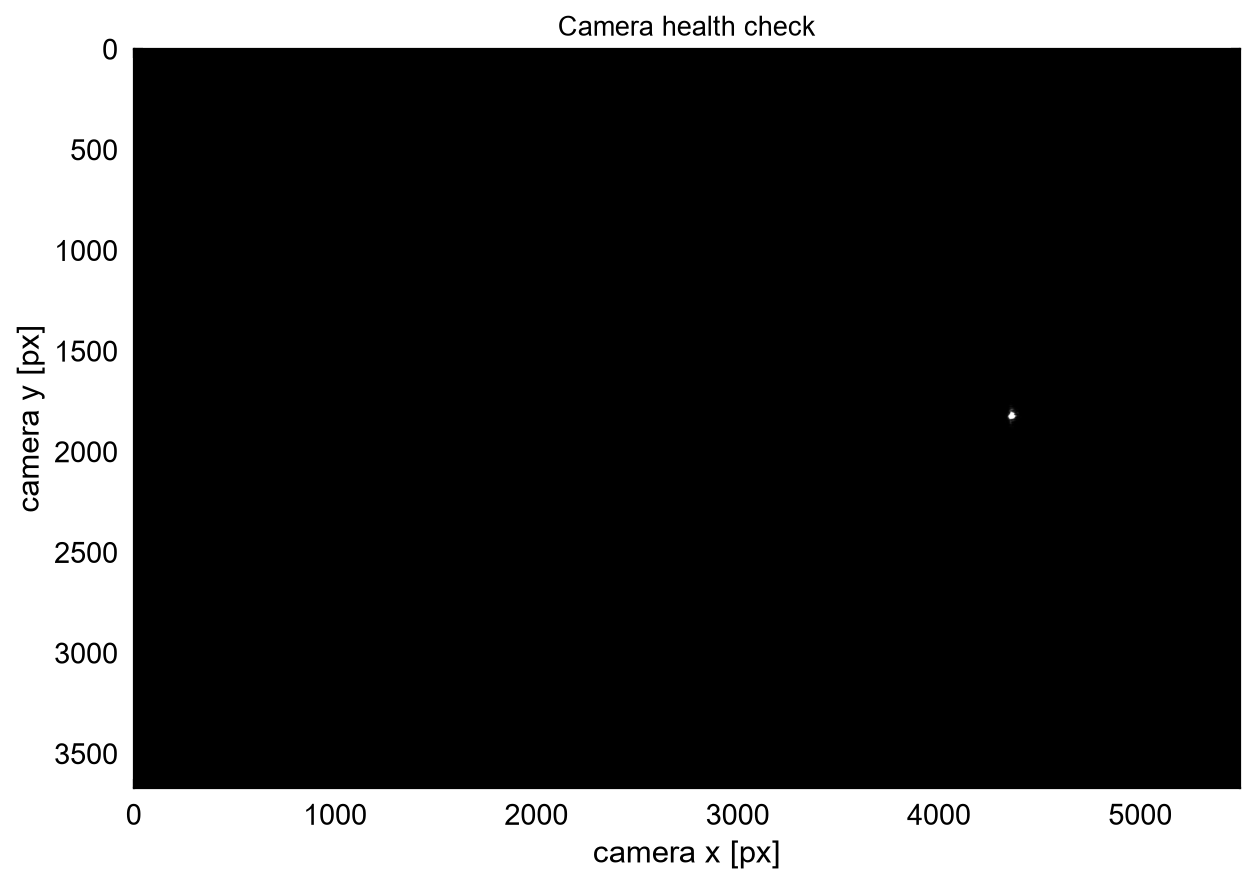

In [3]:
# ============================================================
# CELL 2 — Camera health check
# Do NOT reinitialize the camera
# ============================================================

cam.set_exposure(100e-6)

print("Requested exposure: 100 us")
print("Actual exposure [us]:", cam.exposure_s * 1e6)

cam.flush()

test_img = cam.get_image()

print("\nImage acquired successfully.")
print("Shape:", test_img.shape)
print("Min:", test_img.min())
print("Max:", test_img.max())
print("Mean:", test_img.mean())

plt.figure(figsize=(10, 6))
plt.imshow(
    test_img,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=min(100, test_img.max())
)
plt.title("Camera health check")
plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.show()

In [4]:
# ============================================================
# CELL 3 — Load the post-wavefront Fourier calibration
# ============================================================

fs.load_calibration(
    "fourier",
    str(FOURIER_POST_PATH)
)

print("Current calibration keys:")
print(fs.calibrations.keys())

print("\nFourier M:")
print(fs.calibrations["fourier"]["M"])

print("\nFourier a:")
print(fs.calibrations["fourier"]["a"])

print("\nFourier b:")
print(fs.calibrations["fourier"]["b"])


# ------------------------------------------------------------
# Verify expected mapping
# ------------------------------------------------------------

kxy_zero = np.array([0.0, 0.0])
kxy_carrier = np.array([0.00593203125, 0.0])

ij_zero = fs.kxyslm_to_ijcam(kxy_zero)
ij_carrier = fs.kxyslm_to_ijcam(kxy_carrier)

print("\nZERO ORDER:")
print(ij_zero)

print("\n16-pixel carrier:")
print(ij_carrier)

print("\nCarrier displacement:")
print(ij_carrier - ij_zero)

print("\nWavefront correction still installed:")
print("phase" in slm.source)

Current calibration keys:
dict_keys(['fourier'])

Fourier M:
[[-1.06378567e+05 -7.14228763e+01]
 [-2.74174338e+01  1.04102520e+05]]

Fourier a:
[[0]
 [0]]

Fourier b:
[[4362.25902077]
 [1821.8518376 ]]

ZERO ORDER:
[[4362.25902077]
 [1821.8518376 ]]

16-pixel carrier:
[[3731.2180387 ]
 [1821.68919653]]

Carrier displacement:
[[-6.31040982e+02]
 [-1.62641074e-01]]

Wavefront correction still installed:
False


In [5]:
# ============================================================
# CELL 4 — Install the wavefront correction
# ============================================================

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)

print("Loaded wavefront phase shape:", wavefront_phase.shape)
print("All finite:", np.all(np.isfinite(wavefront_phase)))

# Install correction into slmsuite
slm.source["phase"] = wavefront_phase

print("\nWavefront correction installed:")
print("phase" in slm.source)

print("\nslm.source keys:")
print(slm.source.keys())

print("\nslm.phase_correct =", slm.phase_correct)

Loaded wavefront phase shape: (1200, 1920)
All finite: True

Wavefront correction installed:
True

slm.source keys:
dict_keys(['phase'])

slm.phase_correct = True


In [6]:
# ============================================================
# CELL 5 — Inspect WGS / SpotHologram API
# ============================================================

import inspect
from slmsuite.holography.algorithms import SpotHologram

print("SpotHologram constructor:")
print(inspect.signature(SpotHologram))

print("\n" + "="*70)
print("optimize():")
print(inspect.signature(SpotHologram.optimize))

print("\nOptimize docstring:")
print(inspect.getdoc(SpotHologram.optimize))

print("\n" + "="*70)
print("Methods containing 'feedback', 'measure', or 'stats':")

for name in dir(SpotHologram):
    if (
        ("feedback" in name.lower()) or
        ("measure" in name.lower()) or
        ("stat" in name.lower())
    ):
        attr = getattr(SpotHologram, name)
        if callable(attr):
            print("\n" + name)
            try:
                print(inspect.signature(attr))
            except Exception:
                pass

SpotHologram constructor:
(shape, spot_vectors, basis='kxy', spot_amp=None, cameraslm=None, null_vectors=None, null_radius=None, null_region=None, null_region_radius_frac=None, **kwargs)

optimize():
(self, method='GS', maxiter=20, verbose=True, callback=None, feedback=None, stat_groups=[], **kwargs)

Optimize docstring:
Optimizers to solve the "phase problem": approximating the nearfield phase that
transforms a known nearfield source amplitude to a desired farfield
target amplitude.
Supported optimization methods include:

-   Gerchberg-Saxton (GS) phase retrieval.

    - ``'GS'``

      `An iterative algorithm for phase retrieval
      <http://www.u.arizona.edu/~ppoon/GerchbergandSaxton1972.pdf>`_,
      accomplished by moving back and forth between the imaging and Fourier domains,
      with amplitude corrections applied to each.
      This is usually implemented using fast discrete Fourier transforms,
      potentially GPU-accelerated.

-   Weighted Gerchberg-Saxton (WGS) phase ret

In [8]:
# ============================================================
# CELL 6 — Create 10×10 SpotHologram target
# Correct absolute knm coordinates
# Nothing optimized or displayed yet
# ============================================================

from slmsuite.holography.algorithms import SpotHologram

NX_SPOTS = 10
NY_SPOTS = 10

PITCH_KNM = 13.0

# Computational Fourier grid
NY_FFT = 2048
NX_FFT = 2048

FFT_CENTER = np.array([
    NX_FFT / 2,
    NY_FFT / 2
])

# Our physical carrier is +128 knm in x, 0 in y
CARRIER_OFFSET_KNM = np.array([128.0, 0.0])

# Absolute knm coordinate expected by SpotHologram
CENTER_KNM_ABS = FFT_CENTER + CARRIER_OFFSET_KNM


# ------------------------------------------------------------
# Construct 10×10 grid
# ------------------------------------------------------------

x_knm = (
    np.arange(NX_SPOTS) - (NX_SPOTS - 1) / 2
) * PITCH_KNM + CENTER_KNM_ABS[0]

y_knm = (
    np.arange(NY_SPOTS) - (NY_SPOTS - 1) / 2
) * PITCH_KNM + CENTER_KNM_ABS[1]

XX, YY = np.meshgrid(x_knm, y_knm)

spot_vectors_knm = np.vstack([
    XX.ravel(),
    YY.ravel()
])


print("FFT center:")
print(FFT_CENTER)

print("\nAbsolute carrier center:")
print(CENTER_KNM_ABS)

print("\nNumber of spots:")
print(spot_vectors_knm.shape[1])

print("\nx range:")
print(spot_vectors_knm[0].min(), "to", spot_vectors_knm[0].max())

print("\ny range:")
print(spot_vectors_knm[1].min(), "to", spot_vectors_knm[1].max())


# ------------------------------------------------------------
# Construct hologram
# ------------------------------------------------------------

holo_10x10 = SpotHologram(
    shape=(2048, 2048),
    spot_vectors=spot_vectors_knm,
    basis="knm",
    cameraslm=fs,
)

print("\nSpotHologram created successfully.")
print("Hologram shape:", holo_10x10.shape)

print("\nFirst few camera coordinates predicted by calibration:")
print(holo_10x10.spot_ij[:, :5])

FFT center:
[1024. 1024.]

Absolute carrier center:
[1152. 1024.]

Number of spots:
100

x range:
1093.5 to 1210.5

y range:
965.5 to 1082.5

SpotHologram created successfully.
Hologram shape: (2048, 2048)

First few camera coordinates predicted by calibration:
[[4019.81712379 3955.72702405 3891.63692431 3827.54682456 3763.45672482]
 [1539.52872508 1539.51220685 1539.49568861 1539.47917038 1539.46265215]]


  0%|          | 0/20 [00:00<?, ?it/s]


GS phase shape: (1200, 1920)
Phase min: 6.67572e-06
Phase max: 6.283184

Actual exposure [us]: 2009.681
Full-frame max: 255


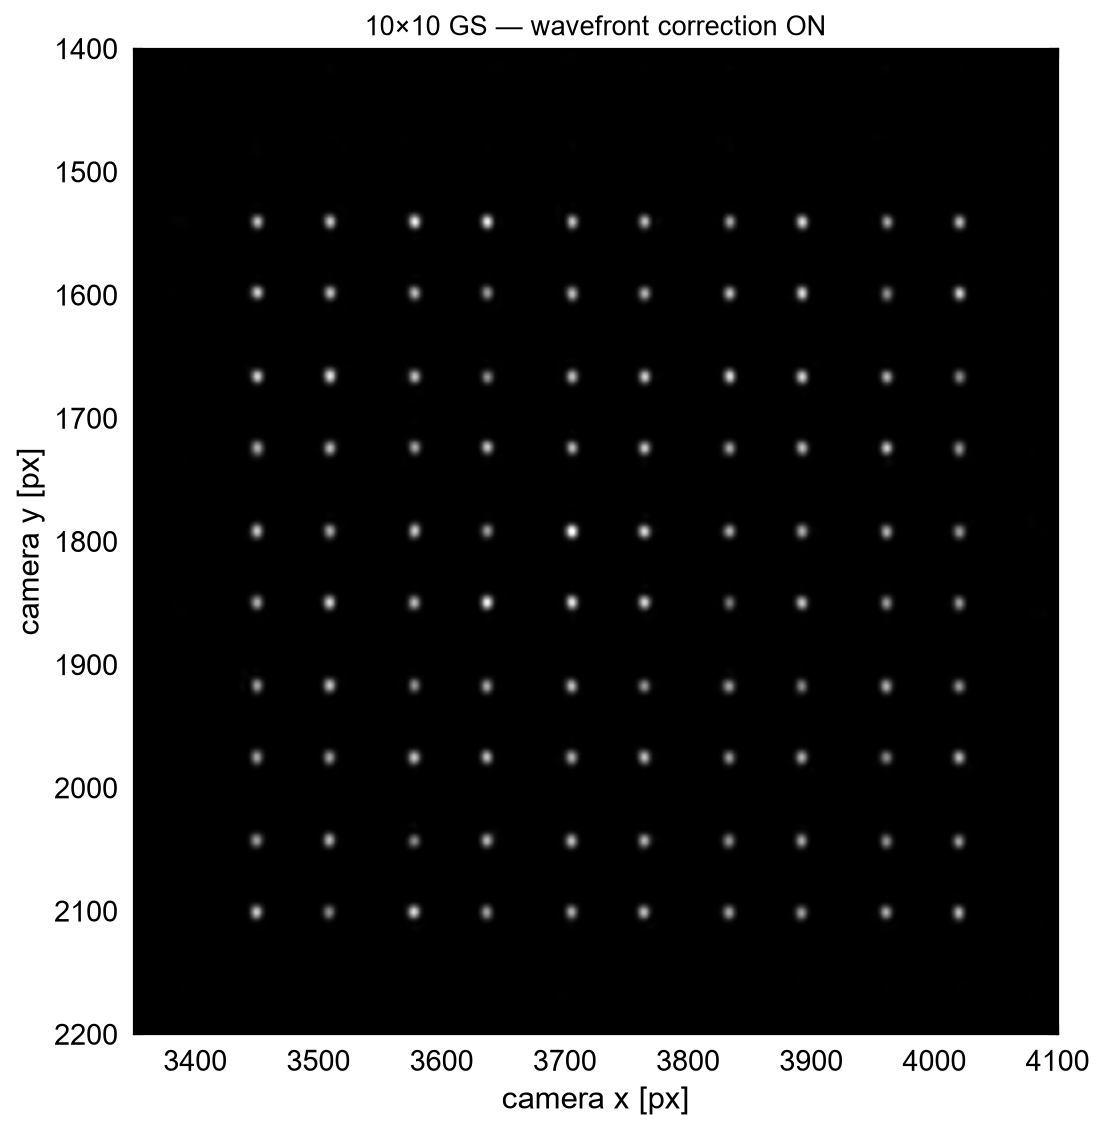

In [9]:
# ============================================================
# CELL 7 — Compute plain 10×10 GS seed
# Then display it WITH wavefront correction ON
# ============================================================

# ------------------------------------------------------------
# 1. Pure computational GS
# ------------------------------------------------------------

holo_10x10.optimize(
    method="GS",
    maxiter=20,
    verbose=True,
)

phase_10x10_gs = holo_10x10.get_phase()

print("\nGS phase shape:", phase_10x10_gs.shape)
print("Phase min:", np.min(phase_10x10_gs))
print("Phase max:", np.max(phase_10x10_gs))


# ------------------------------------------------------------
# 2. Display GS hologram with wavefront correction ON
# ------------------------------------------------------------

slm.set_phase(
    phase_10x10_gs,
    phase_correct=True,
    settle=True
)


# ------------------------------------------------------------
# 3. Acquire camera image
#
# Previous 10×10 work used ~2 ms successfully.
# ------------------------------------------------------------

cam.set_exposure(2e-3)
cam.flush()

img_10x10_gs_corr = cam.get_image()

print("\nActual exposure [us]:", cam.exposure_s * 1e6)
print("Full-frame max:", img_10x10_gs_corr.max())


# ------------------------------------------------------------
# 4. Show region around expected array
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(
    img_10x10_gs_corr,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=min(180, img_10x10_gs_corr.max())
)

plt.xlim(3350, 4100)
plt.ylim(2200, 1400)

plt.xlabel("camera x [px]")
plt.ylabel("camera y [px]")
plt.title("10×10 GS — wavefront correction ON")

plt.show()

spot_ij shape: (2, 100)

SPOT PEAKS
min    : 88
median : 127.0
mean   : 128.2
max    : 187
std    : 18.63491346907734
CV [%] : 14.535813938437864
Saturated spots: 0 / 100

INTEGRATED 13×13 COUNTS
min    : 2402.0
median : 5560.0
mean   : 5753.95
max    : 10565.0
std    : 2094.188164301384
CV [%] : 36.39566148995706


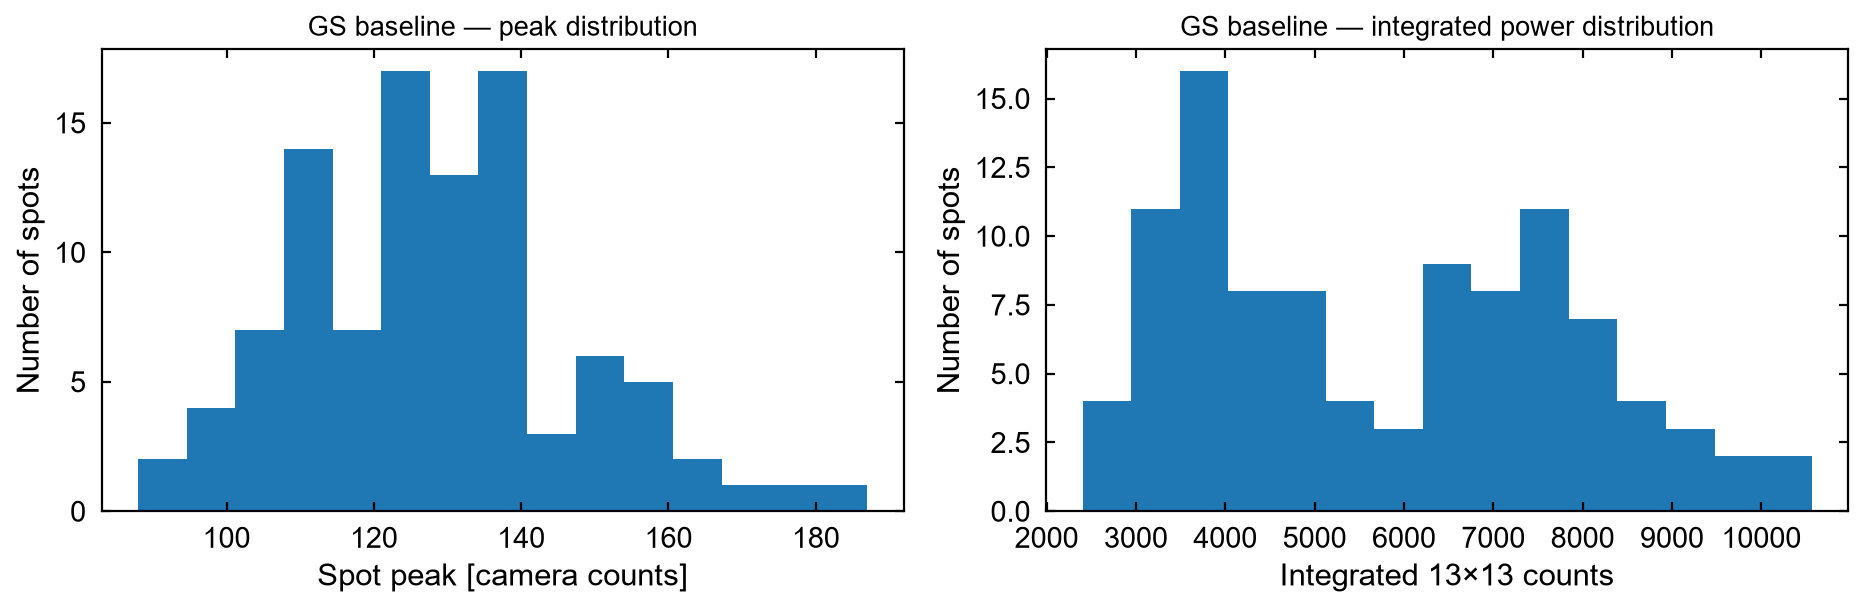

In [10]:
# ============================================================
# CELL 8 — Check 10×10 GS spot intensities
# Baseline before camera-feedback WGS
# ============================================================

spot_ij = np.asarray(holo_10x10.spot_ij)

print("spot_ij shape:", spot_ij.shape)

HALF_WIDTH = 6      # => 13×13 pixel integration box

spot_peaks = []
spot_sums = []

for n in range(spot_ij.shape[1]):

    x = int(round(spot_ij[0, n]))
    y = int(round(spot_ij[1, n]))

    roi = img_10x10_gs_corr[
        y-HALF_WIDTH:y+HALF_WIDTH+1,
        x-HALF_WIDTH:x+HALF_WIDTH+1
    ]

    spot_peaks.append(np.max(roi))
    spot_sums.append(np.sum(roi, dtype=float))


spot_peaks = np.asarray(spot_peaks)
spot_sums = np.asarray(spot_sums)

print("\nSPOT PEAKS")
print("min    :", spot_peaks.min())
print("median :", np.median(spot_peaks))
print("mean   :", spot_peaks.mean())
print("max    :", spot_peaks.max())
print("std    :", spot_peaks.std())
print("CV [%] :", 100 * spot_peaks.std() / spot_peaks.mean())
print("Saturated spots:", np.sum(spot_peaks >= 255), "/ 100")


print("\nINTEGRATED 13×13 COUNTS")
print("min    :", spot_sums.min())
print("median :", np.median(spot_sums))
print("mean   :", spot_sums.mean())
print("max    :", spot_sums.max())
print("std    :", spot_sums.std())
print("CV [%] :", 100 * spot_sums.std() / spot_sums.mean())


# ------------------------------------------------------------
# Show intensity distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(spot_peaks, bins=15)
ax[0].set_xlabel("Spot peak [camera counts]")
ax[0].set_ylabel("Number of spots")
ax[0].set_title("GS baseline — peak distribution")

ax[1].hist(spot_sums, bins=15)
ax[1].set_xlabel("Integrated 13×13 counts")
ax[1].set_ylabel("Number of spots")
ax[1].set_title("GS baseline — integrated power distribution")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 9 — Inspect SpotHologram experimental measurement
# Nothing is optimized yet
# ============================================================

import inspect

print("measure() signature:")
print(inspect.signature(holo_10x10.measure))

print("\nmeasure() docstring:")
print(inspect.getdoc(holo_10x10.measure))

print("\n" + "="*70)

# Useful integration-related attributes
for name in dir(holo_10x10):
    if "integration" in name.lower():
        try:
            value = getattr(holo_10x10, name)
            print(name, "=", value)
        except Exception:
            pass

print("\n" + "="*70)
print("Source of measure():")
print(inspect.getsource(type(holo_10x10).measure))

measure() signature:
(basis='ij')

measure() docstring:
Method to request a measurement to occur. If :attr:`img_ij` is ``None``,
then a new image will be grabbed from the camera (this is done automatically in
algorithms).

Parameters
----------
basis : str
    The cached image to be sure to fill with new data.
    Can be ``"ij"`` or ``"knm"``.

    - If ``"knm"``, then :attr:`img_ij` and :attr:`img_knm` are filled.
    - If ``"ij"``, then :attr:`img_ij` is filled, and :attr:`img_knm` is ignored.

    This is useful to avoid (expensive) transformation from the ``"ij"`` to the
    ``"knm"`` basis if :attr:`img_knm` is not needed.

spot_integration_width_ij = 41
spot_integration_width_knm = 9

Source of measure():
    def measure(self, basis="ij"):
        """
        Method to request a measurement to occur. If :attr:`img_ij` is ``None``,
        then a new image will be grabbed from the camera (this is done automatically in
        algorithms).

        Parameters
        ----------
   

In [12]:
# ============================================================
# CELL 10 — Inspect experimental_spot feedback internals
# Nothing is optimized or changed experimentally
# ============================================================

import inspect

print("="*70)
print("_calculate_stats_experimental_spot:")
print(inspect.getsource(
    type(holo_10x10)._calculate_stats_experimental_spot
))

print("\n" + "="*70)
print("Methods containing 'weight' or 'feedback':")

for name in dir(holo_10x10):
    if ("weight" in name.lower()) or ("feedback" in name.lower()):
        attr = getattr(type(holo_10x10), name, None)

        if callable(attr):
            print("\n" + name)
            try:
                print(inspect.signature(attr))
            except Exception:
                pass

_calculate_stats_experimental_spot:
    def _calculate_stats_experimental_spot(self, stats, stat_groups=[]):
        """
        Wrapped by :meth:`._update_stats()`.
        """
        if "experimental_spot" in stat_groups:
            self.measure(basis="ij")

            pwr_img = np.square(self.img_ij)

            pwr_feedback = analysis.take(
                pwr_img,
                self.spot_ij,
                self.spot_integration_width_ij,
                centered=True,
                integrate=True,
            )

            stats["experimental_spot"] = self._calculate_stats(
                np.sqrt(pwr_feedback),
                self.spot_amp,
                xp=np,
                efficiency_compensation=False,
                total=np.sum(pwr_img),
                raw="raw_stats" in self.flags and self.flags["raw_stats"],
            )

        if "external_spot" in stat_groups:
            pwr_feedback = np.square(np.array(self.external_spot_amp, copy=(False if np.__ve

Integration width [camera px]:
41

MEASURED SPOT POWER
min    : 3640.000014424324
median : 5558.500023663044
mean   : 5549.599992260933
max    : 8385.999908685684
std    : 857.6292548582785
CV [%] : 15.453893182468388

MEASURED SPOT AMPLITUDE
min    : 60.33241263553384
median : 74.55526660747853
mean   : 74.2746845044376
max    : 91.5751052889686
std    : 5.73334405274883
CV [%] : 7.7191092644847075


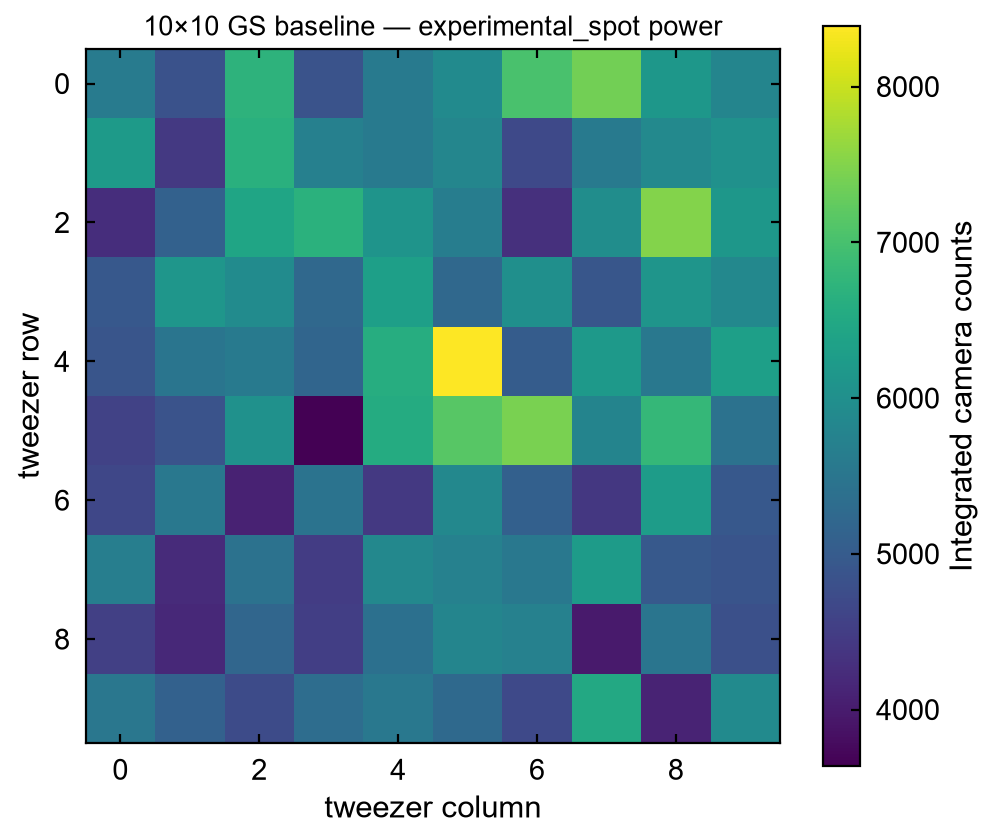

In [13]:
# ============================================================
# CELL 11 — Measure the exact experimental_spot feedback
# No WGS update yet
# ============================================================

from slmsuite.holography import analysis

# Force a fresh camera image.
holo_10x10.img_ij = None
holo_10x10.img_knm = None

# This automatically displays the current GS hologram.
# Because slm.phase_correct == True, the WF correction is applied.
holo_10x10.measure(basis="ij")


# ------------------------------------------------------------
# Reproduce exactly what experimental_spot uses
# ------------------------------------------------------------

pwr_img = np.square(holo_10x10.img_ij)

pwr_feedback = analysis.take(
    pwr_img,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback = np.sqrt(pwr_feedback)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("Integration width [camera px]:")
print(holo_10x10.spot_integration_width_ij)

print("\nMEASURED SPOT POWER")
print("min    :", pwr_feedback.min())
print("median :", np.median(pwr_feedback))
print("mean   :", pwr_feedback.mean())
print("max    :", pwr_feedback.max())
print("std    :", pwr_feedback.std())
print("CV [%] :", 100 * pwr_feedback.std() / pwr_feedback.mean())

print("\nMEASURED SPOT AMPLITUDE")
print("min    :", amp_feedback.min())
print("median :", np.median(amp_feedback))
print("mean   :", amp_feedback.mean())
print("max    :", amp_feedback.max())
print("std    :", amp_feedback.std())
print("CV [%] :", 100 * amp_feedback.std() / amp_feedback.mean())


# ------------------------------------------------------------
# Visualize the 10×10 measured power map
# ------------------------------------------------------------

power_map = pwr_feedback.reshape(10, 10)

plt.figure(figsize=(7, 6))
im = plt.imshow(power_map, cmap="viridis", origin="upper")
plt.colorbar(im, label="Integrated camera counts")
plt.title("10×10 GS baseline — experimental_spot power")
plt.xlabel("tweezer column")
plt.ylabel("tweezer row")
plt.show()

In [14]:
# ============================================================
# CELL 12 — First experimental WGS test: 5 iterations
# Starts from the existing 10×10 GS solution
# Wavefront correction remains ON
# ============================================================

# Save the GS starting point before WGS modifies the hologram
phase_10x10_gs_before_wgs = holo_10x10.get_phase().copy()
weights_10x10_gs_before_wgs = holo_10x10.get_weights().copy()

print("Wavefront correction installed:",
      "phase" in slm.source)

print("slm.phase_correct:",
      slm.phase_correct)

print("\nStarting 5 camera-feedback WGS iterations...\n")


holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=5,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


print("\nFinished 5 WGS iterations.")


# ------------------------------------------------------------
# Display the resulting hologram explicitly
# ------------------------------------------------------------

phase_10x10_wgs5 = holo_10x10.get_phase().copy()

slm.set_phase(
    phase_10x10_wgs5,
    phase_correct=True,
    settle=True
)

cam.flush()
img_10x10_wgs5 = cam.get_image()

print("Camera exposure [us]:", cam.exposure_s * 1e6)
print("Full-frame max:", img_10x10_wgs5.max())

Wavefront correction installed: True
slm.phase_correct: True

Starting 5 camera-feedback WGS iterations...



  0%|          | 0/5 [00:00<?, ?it/s]


Finished 5 WGS iterations.
Camera exposure [us]: 2009.681
Full-frame max: 255


BEFORE WGS
Power CV [%]     : 15.4539
Amplitude CV [%] : 7.7191

AFTER 5 WGS ITERATIONS
Power min        : 5434.00000500679
Power median     : 5798.999923348427
Power mean       : 5801.239975241423
Power max        : 6202.999982357025
Power CV [%]     : 2.9509493669849634

Amplitude CV [%] : 1.475889254676478


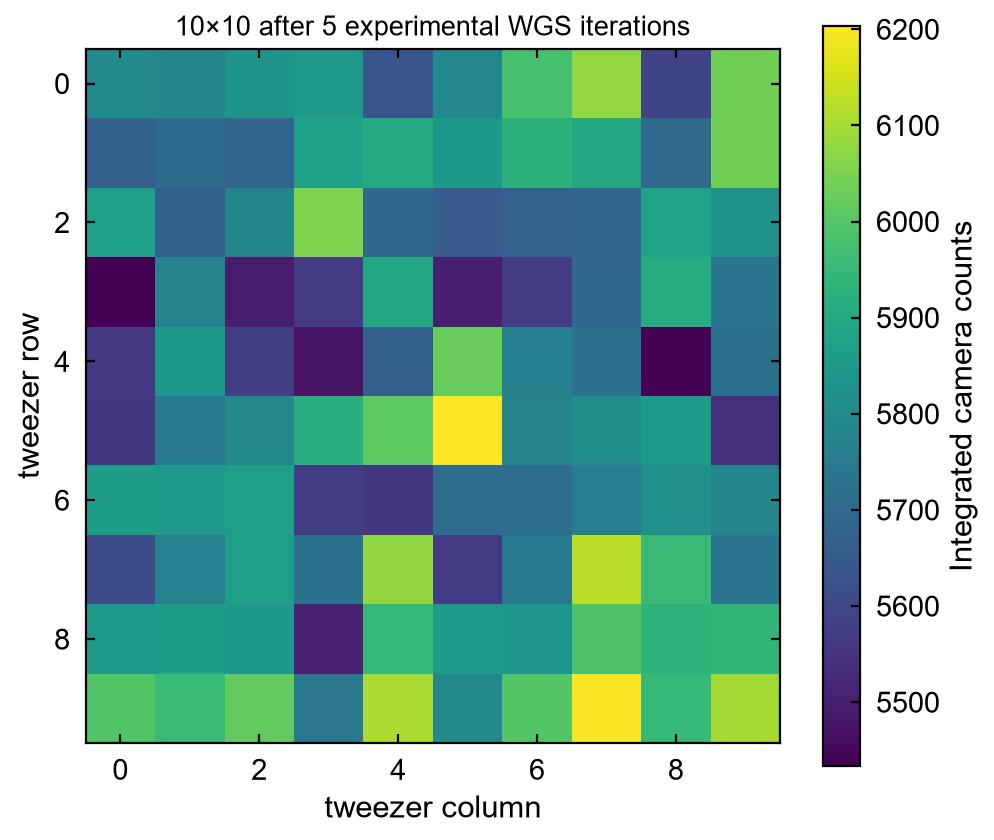

In [15]:
# ============================================================
# CELL 13 — Measure uniformity after 5 WGS iterations
# ============================================================

from slmsuite.holography import analysis

# Force a genuinely fresh camera measurement
holo_10x10.img_ij = None
holo_10x10.img_knm = None

# Final WGS phase is already in holo_10x10.
# measure() displays it and acquires a fresh camera frame.
holo_10x10.measure(basis="ij")


# ------------------------------------------------------------
# Reproduce experimental_spot feedback exactly
# ------------------------------------------------------------

pwr_img_wgs5 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs5 = analysis.take(
    pwr_img_wgs5,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs5 = np.sqrt(pwr_feedback_wgs5)


# ------------------------------------------------------------
# Calculate CVs
# ------------------------------------------------------------

power_cv_wgs5 = (
    100 * pwr_feedback_wgs5.std() / pwr_feedback_wgs5.mean()
)

amp_cv_wgs5 = (
    100 * amp_feedback_wgs5.std() / amp_feedback_wgs5.mean()
)


print("BEFORE WGS")
print("Power CV [%]     : 15.4539")
print("Amplitude CV [%] : 7.7191")

print("\nAFTER 5 WGS ITERATIONS")
print("Power min        :", pwr_feedback_wgs5.min())
print("Power median     :", np.median(pwr_feedback_wgs5))
print("Power mean       :", pwr_feedback_wgs5.mean())
print("Power max        :", pwr_feedback_wgs5.max())
print("Power CV [%]     :", power_cv_wgs5)

print("\nAmplitude CV [%] :", amp_cv_wgs5)


# ------------------------------------------------------------
# 10×10 power map
# ------------------------------------------------------------

power_map_wgs5 = pwr_feedback_wgs5.reshape(10, 10)

plt.figure(figsize=(7, 6))

im = plt.imshow(
    power_map_wgs5,
    cmap="viridis",
    origin="upper"
)

plt.colorbar(im, label="Integrated camera counts")

plt.title("10×10 after 5 experimental WGS iterations")
plt.xlabel("tweezer column")
plt.ylabel("tweezer row")

plt.show()

In [16]:
# ============================================================
# CELL 14 — Checkpoint WGS5, then continue to WGS10
# ============================================================

# ------------------------------------------------------------
# Save the excellent 5-iteration state in memory
# ------------------------------------------------------------

phase_10x10_wgs5_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs5_checkpoint = holo_10x10.get_weights().copy()

power_cv_wgs5_checkpoint = power_cv_wgs5
amp_cv_wgs5_checkpoint = amp_cv_wgs5

print("Checkpoint WGS5:")
print("Power CV [%]     :", power_cv_wgs5_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs5_checkpoint)


# ------------------------------------------------------------
# Continue SAME hologram for 5 additional WGS iterations
# ------------------------------------------------------------

holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=5,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


# ------------------------------------------------------------
# Fresh measurement of resulting WGS10 state
# ------------------------------------------------------------

holo_10x10.img_ij = None
holo_10x10.img_knm = None

holo_10x10.measure(basis="ij")

pwr_img_wgs10 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs10 = analysis.take(
    pwr_img_wgs10,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs10 = np.sqrt(pwr_feedback_wgs10)

power_cv_wgs10 = (
    100 * pwr_feedback_wgs10.std() / pwr_feedback_wgs10.mean()
)

amp_cv_wgs10 = (
    100 * amp_feedback_wgs10.std() / amp_feedback_wgs10.mean()
)


print("\n========================================")
print("CONVERGENCE")
print("========================================")

print("GS baseline")
print("Power CV [%]     : 15.4539")
print("Amplitude CV [%] : 7.7191")

print("\nWGS5")
print("Power CV [%]     :", power_cv_wgs5_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs5_checkpoint)

print("\nWGS10")
print("Power CV [%]     :", power_cv_wgs10)
print("Amplitude CV [%] :", amp_cv_wgs10)

print("\nWGS10 power range:")
print("min  :", pwr_feedback_wgs10.min())
print("mean :", pwr_feedback_wgs10.mean())
print("max  :", pwr_feedback_wgs10.max())

Checkpoint WGS5:
Power CV [%]     : 2.9509493669849634
Amplitude CV [%] : 1.475889254676478


  0%|          | 0/5 [00:00<?, ?it/s]


CONVERGENCE
GS baseline
Power CV [%]     : 15.4539
Amplitude CV [%] : 7.7191

WGS5
Power CV [%]     : 2.9509493669849634
Amplitude CV [%] : 1.475889254676478

WGS10
Power CV [%]     : 2.370898889565443
Amplitude CV [%] : 1.1841802081733726

WGS10 power range:
min  : 9356.99996471405
mean : 9911.579971605539
max  : 10611.999944329262


In [17]:
# ============================================================
# CELL 15 — Check WGS10 tweezer saturation
# ============================================================

HALF_WIDTH = 20     # 41×41 region, same scale as experimental_spot

spot_peak_wgs10 = []

for n in range(holo_10x10.spot_ij.shape[1]):

    x = int(round(holo_10x10.spot_ij[0, n]))
    y = int(round(holo_10x10.spot_ij[1, n]))

    roi = pwr_img_wgs10[
        y-HALF_WIDTH:y+HALF_WIDTH+1,
        x-HALF_WIDTH:x+HALF_WIDTH+1
    ]

    spot_peak_wgs10.append(np.max(roi))

spot_peak_wgs10 = np.asarray(spot_peak_wgs10)


print("WGS10 raw tweezer peaks:")
print("min    :", spot_peak_wgs10.min())
print("median :", np.median(spot_peak_wgs10))
print("mean   :", spot_peak_wgs10.mean())
print("max    :", spot_peak_wgs10.max())

print("\nSpots >= 250 counts:",
      np.sum(spot_peak_wgs10 >= 250), "/ 100")

print("Spots == 255 counts:",
      np.sum(spot_peak_wgs10 >= 255), "/ 100")

WGS10 raw tweezer peaks:
min    : 119.00001
median : 135.99998
mean   : 135.99
max    : 150.0

Spots >= 250 counts: 0 / 100
Spots == 255 counts: 0 / 100


In [18]:
# ============================================================
# CELL 16 — Checkpoint WGS10 and continue to WGS20
# ============================================================

# ------------------------------------------------------------
# Save WGS10 state in memory
# ------------------------------------------------------------

phase_10x10_wgs10_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs10_checkpoint = holo_10x10.get_weights().copy()

power_cv_wgs10_checkpoint = power_cv_wgs10
amp_cv_wgs10_checkpoint = amp_cv_wgs10

print("Checkpoint WGS10 saved.")
print("Power CV [%]     :", power_cv_wgs10_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs10_checkpoint)


# ------------------------------------------------------------
# Continue SAME hologram for 10 additional WGS iterations
# ------------------------------------------------------------

holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


# ------------------------------------------------------------
# Fresh WGS20 measurement
# ------------------------------------------------------------

holo_10x10.img_ij = None
holo_10x10.img_knm = None

holo_10x10.measure(basis="ij")

pwr_img_wgs20 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs20 = analysis.take(
    pwr_img_wgs20,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs20 = np.sqrt(pwr_feedback_wgs20)

power_cv_wgs20 = (
    100 * pwr_feedback_wgs20.std() / pwr_feedback_wgs20.mean()
)

amp_cv_wgs20 = (
    100 * amp_feedback_wgs20.std() / amp_feedback_wgs20.mean()
)


print("\n========================================")
print("CONVERGENCE")
print("========================================")

print("GS")
print("Power CV [%]     : 15.4539")
print("Amplitude CV [%] : 7.7191")

print("\nWGS5")
print("Power CV [%]     : 2.9509493669849634")
print("Amplitude CV [%] : 1.475889254676478")

print("\nWGS10")
print("Power CV [%]     :", power_cv_wgs10_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs10_checkpoint)

print("\nWGS20")
print("Power CV [%]     :", power_cv_wgs20)
print("Amplitude CV [%] :", amp_cv_wgs20)

print("\nWGS20 power range:")
print("min  :", pwr_feedback_wgs20.min())
print("mean :", pwr_feedback_wgs20.mean())
print("max  :", pwr_feedback_wgs20.max())

Checkpoint WGS10 saved.
Power CV [%]     : 2.370898889565443
Amplitude CV [%] : 1.1841802081733726


  0%|          | 0/10 [00:00<?, ?it/s]


CONVERGENCE
GS
Power CV [%]     : 15.4539
Amplitude CV [%] : 7.7191

WGS5
Power CV [%]     : 2.9509493669849634
Amplitude CV [%] : 1.475889254676478

WGS10
Power CV [%]     : 2.370898889565443
Amplitude CV [%] : 1.1841802081733726

WGS20
Power CV [%]     : 1.7903183475694273
Amplitude CV [%] : 0.894004760658728

WGS20 power range:
min  : 6928.999980688095
mean : 7210.479991850853
max  : 7587.999977111816


In [19]:
# ============================================================
# CELL 17 — Checkpoint WGS20 and continue to WGS30
# ============================================================

# Save WGS20 state
phase_10x10_wgs20_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs20_checkpoint = holo_10x10.get_weights().copy()

power_cv_wgs20_checkpoint = power_cv_wgs20
amp_cv_wgs20_checkpoint = amp_cv_wgs20

print("Checkpoint WGS20 saved.")
print("Power CV [%]     :", power_cv_wgs20_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs20_checkpoint)


# ------------------------------------------------------------
# Continue for 10 more WGS iterations
# ------------------------------------------------------------

holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


# ------------------------------------------------------------
# Fresh WGS30 measurement
# ------------------------------------------------------------

holo_10x10.img_ij = None
holo_10x10.img_knm = None

holo_10x10.measure(basis="ij")

pwr_img_wgs30 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs30 = analysis.take(
    pwr_img_wgs30,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs30 = np.sqrt(pwr_feedback_wgs30)

power_cv_wgs30 = (
    100 * pwr_feedback_wgs30.std() / pwr_feedback_wgs30.mean()
)

amp_cv_wgs30 = (
    100 * amp_feedback_wgs30.std() / amp_feedback_wgs30.mean()
)

print("\n========================================")
print("CONVERGENCE")
print("========================================")

print("GS    Power CV [%] :", 15.4539)
print("WGS5  Power CV [%] :", 2.9509493669849634)
print("WGS10 Power CV [%] :", power_cv_wgs10_checkpoint)
print("WGS20 Power CV [%] :", power_cv_wgs20_checkpoint)
print("WGS30 Power CV [%] :", power_cv_wgs30)

print("\nWGS30 amplitude CV [%] :", amp_cv_wgs30)

print("\nWGS30 power range:")
print("min  :", pwr_feedback_wgs30.min())
print("mean :", pwr_feedback_wgs30.mean())
print("max  :", pwr_feedback_wgs30.max())

Checkpoint WGS20 saved.
Power CV [%]     : 1.7903183475694273
Amplitude CV [%] : 0.894004760658728


  0%|          | 0/10 [00:00<?, ?it/s]


CONVERGENCE
GS    Power CV [%] : 15.4539
WGS5  Power CV [%] : 2.9509493669849634
WGS10 Power CV [%] : 2.370898889565443
WGS20 Power CV [%] : 1.7903183475694273
WGS30 Power CV [%] : 1.1657106702218316

WGS30 amplitude CV [%] : 0.5827321595368088

WGS30 power range:
min  : 7947.00000667572
mean : 8216.039996608495
max  : 8461.999987363815


In [20]:
# ============================================================
# CELL 18 — Checkpoint WGS30 and continue to WGS40
# ============================================================

# Save WGS30 state
phase_10x10_wgs30_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs30_checkpoint = holo_10x10.get_weights().copy()

power_cv_wgs30_checkpoint = power_cv_wgs30
amp_cv_wgs30_checkpoint = amp_cv_wgs30

print("Checkpoint WGS30 saved.")
print("Power CV [%]     :", power_cv_wgs30_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs30_checkpoint)


# ------------------------------------------------------------
# Continue for 10 more WGS iterations
# ------------------------------------------------------------

holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


# ------------------------------------------------------------
# Fresh WGS40 measurement
# ------------------------------------------------------------

holo_10x10.img_ij = None
holo_10x10.img_knm = None

holo_10x10.measure(basis="ij")

pwr_img_wgs40 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs40 = analysis.take(
    pwr_img_wgs40,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs40 = np.sqrt(pwr_feedback_wgs40)

power_cv_wgs40 = (
    100 * pwr_feedback_wgs40.std() / pwr_feedback_wgs40.mean()
)

amp_cv_wgs40 = (
    100 * amp_feedback_wgs40.std() / amp_feedback_wgs40.mean()
)

print("\n========================================")
print("CONVERGENCE")
print("========================================")

print("GS    Power CV [%] :", 15.4539)
print("WGS5  Power CV [%] :", 2.9509493669849634)
print("WGS10 Power CV [%] :", power_cv_wgs10_checkpoint)
print("WGS20 Power CV [%] :", power_cv_wgs20_checkpoint)
print("WGS30 Power CV [%] :", power_cv_wgs30_checkpoint)
print("WGS40 Power CV [%] :", power_cv_wgs40)

print("\nWGS40 amplitude CV [%] :", amp_cv_wgs40)

print("\nWGS40 power range:")
print("min  :", pwr_feedback_wgs40.min())
print("mean :", pwr_feedback_wgs40.mean())
print("max  :", pwr_feedback_wgs40.max())

Checkpoint WGS30 saved.
Power CV [%]     : 1.1657106702218316
Amplitude CV [%] : 0.5827321595368088


  0%|          | 0/10 [00:00<?, ?it/s]


CONVERGENCE
GS    Power CV [%] : 15.4539
WGS5  Power CV [%] : 2.9509493669849634
WGS10 Power CV [%] : 2.370898889565443
WGS20 Power CV [%] : 1.7903183475694273
WGS30 Power CV [%] : 1.1657106702218316
WGS40 Power CV [%] : 1.2915274028535704

WGS40 amplitude CV [%] : 0.6444089335779367

WGS40 power range:
min  : 7614.000009298325
mean : 7816.029993832111
max  : 8101.999982953072


In [21]:
# ============================================================
# CELL 19 — Checkpoint WGS40 and continue to WGS50
# ============================================================

# ------------------------------------------------------------
# Save WGS40 state
# ------------------------------------------------------------

phase_10x10_wgs40_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs40_checkpoint = holo_10x10.get_weights().copy()

power_cv_wgs40_checkpoint = power_cv_wgs40
amp_cv_wgs40_checkpoint = amp_cv_wgs40

print("Checkpoint WGS40 saved.")
print("Power CV [%]     :", power_cv_wgs40_checkpoint)
print("Amplitude CV [%] :", amp_cv_wgs40_checkpoint)


# ------------------------------------------------------------
# Continue SAME solution for 10 more iterations -> WGS50
# ------------------------------------------------------------

holo_10x10.optimize(
    method="WGS-Leonardo",
    maxiter=10,
    feedback="experimental_spot",
    feedback_exponent=0.5,
    stat_groups=["experimental_spot"],
    verbose=True,
)


# ------------------------------------------------------------
# Fresh WGS50 measurement
# ------------------------------------------------------------

holo_10x10.img_ij = None
holo_10x10.img_knm = None

holo_10x10.measure(basis="ij")

pwr_img_wgs50 = np.square(holo_10x10.img_ij)

pwr_feedback_wgs50 = analysis.take(
    pwr_img_wgs50,
    holo_10x10.spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs50 = np.sqrt(pwr_feedback_wgs50)

power_cv_wgs50 = (
    100 * pwr_feedback_wgs50.std() / pwr_feedback_wgs50.mean()
)

amp_cv_wgs50 = (
    100 * amp_feedback_wgs50.std() / amp_feedback_wgs50.mean()
)

phase_10x10_wgs50_checkpoint = holo_10x10.get_phase().copy()
weights_10x10_wgs50_checkpoint = holo_10x10.get_weights().copy()


print("\n========================================")
print("FULL CONVERGENCE")
print("========================================")

print("GS    Power CV [%] :", 15.4539)
print("WGS5  Power CV [%] :", 2.9509493669849634)
print("WGS10 Power CV [%] :", power_cv_wgs10_checkpoint)
print("WGS20 Power CV [%] :", power_cv_wgs20_checkpoint)
print("WGS30 Power CV [%] :", power_cv_wgs30_checkpoint)
print("WGS40 Power CV [%] :", power_cv_wgs40_checkpoint)
print("WGS50 Power CV [%] :", power_cv_wgs50)

print("\nWGS50 amplitude CV [%] :", amp_cv_wgs50)

print("\nWGS50 power range:")
print("min  :", pwr_feedback_wgs50.min())
print("mean :", pwr_feedback_wgs50.mean())
print("max  :", pwr_feedback_wgs50.max())

Checkpoint WGS40 saved.
Power CV [%]     : 1.2915274028535704
Amplitude CV [%] : 0.6444089335779367


  0%|          | 0/10 [00:00<?, ?it/s]


FULL CONVERGENCE
GS    Power CV [%] : 15.4539
WGS5  Power CV [%] : 2.9509493669849634
WGS10 Power CV [%] : 2.370898889565443
WGS20 Power CV [%] : 1.7903183475694273
WGS30 Power CV [%] : 1.1657106702218316
WGS40 Power CV [%] : 1.2915274028535704
WGS50 Power CV [%] : 1.0073606269068156

WGS50 amplitude CV [%] : 0.5038012130415388

WGS50 power range:
min  : 7981.999979257584
mean : 8180.819990648031
max  : 8362.00002002716


In [22]:
# ============================================================
# CELL 20 — Save WGS checkpoints + convergence data
# ============================================================

from pathlib import Path
import numpy as np

WGS_SAVE_DIR = FOURIER_POST_PATH.parent / "10x10_WGS_20260904"
WGS_SAVE_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Save phases
# ------------------------------------------------------------

np.save(
    WGS_SAVE_DIR / "10x10_GS_phase.npy",
    phase_10x10_gs_before_wgs
)

np.save(
    WGS_SAVE_DIR / "10x10_WGS30_phase.npy",
    phase_10x10_wgs30_checkpoint
)

np.save(
    WGS_SAVE_DIR / "10x10_WGS40_phase.npy",
    phase_10x10_wgs40_checkpoint
)

np.save(
    WGS_SAVE_DIR / "10x10_WGS50_phase.npy",
    phase_10x10_wgs50_checkpoint
)


# ------------------------------------------------------------
# Save WGS weights
# ------------------------------------------------------------

np.save(
    WGS_SAVE_DIR / "10x10_WGS30_weights.npy",
    weights_10x10_wgs30_checkpoint
)

np.save(
    WGS_SAVE_DIR / "10x10_WGS40_weights.npy",
    weights_10x10_wgs40_checkpoint
)

np.save(
    WGS_SAVE_DIR / "10x10_WGS50_weights.npy",
    weights_10x10_wgs50_checkpoint
)


# ------------------------------------------------------------
# Save convergence table
# ------------------------------------------------------------

iterations = np.array([0, 5, 10, 20, 30, 40, 50])

power_cv = np.array([
    15.4539,
    2.9509493669849634,
    power_cv_wgs10_checkpoint,
    power_cv_wgs20_checkpoint,
    power_cv_wgs30_checkpoint,
    power_cv_wgs40_checkpoint,
    power_cv_wgs50,
])

np.savetxt(
    WGS_SAVE_DIR / "10x10_WGS_convergence.csv",
    np.column_stack([iterations, power_cv]),
    delimiter=",",
    header="WGS_iterations,power_CV_percent",
    comments=""
)

print("Saved WGS data to:")
print(WGS_SAVE_DIR)

print("\nSaved convergence:")
for n, cv in zip(iterations, power_cv):
    print(f"{n:2d} iterations : {cv:.4f} %")

Saved WGS data to:
C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\10x10_WGS_20260904

Saved convergence:
 0 iterations : 15.4539 %
 5 iterations : 2.9509 %
10 iterations : 2.3709 %
20 iterations : 1.7903 %
30 iterations : 1.1657 %
40 iterations : 1.2915 %
50 iterations : 1.0074 %


Exposure [us]: 2009.681
Full-frame max: 255

WGS30 — 10×10 ARRAY STATISTICS

RAW SPOT PEAKS [camera counts]
------------------------------
min        : 109
median     : 119.0
mean       : 118.66
max        : 128
std        : 4.224263249372606
CV [%]     : 3.5599723996061066
max/min    : 1.1743119266055047

Saturated spots: 0 / 100

INTEGRATED SPOT POWER [41×41 counts]
------------------------------------
min        : 8534.0
median     : 8743.0
mean       : 8757.74
max        : 9104.0
std        : 95.57003923824664
CV [%]     : 1.0912637191586716
max/min    : 1.0667916569018046

SPOT AMPLITUDE [sqrt(counts)]
-----------------------------
min        : 92.37965143904798
median     : 93.5040106091712
mean       : 93.58140983493732
max        : 95.4148835350125
std        : 0.5096403687911446
CV [%]     : 0.5445957372196775
max/min    : 1.0328560678535053


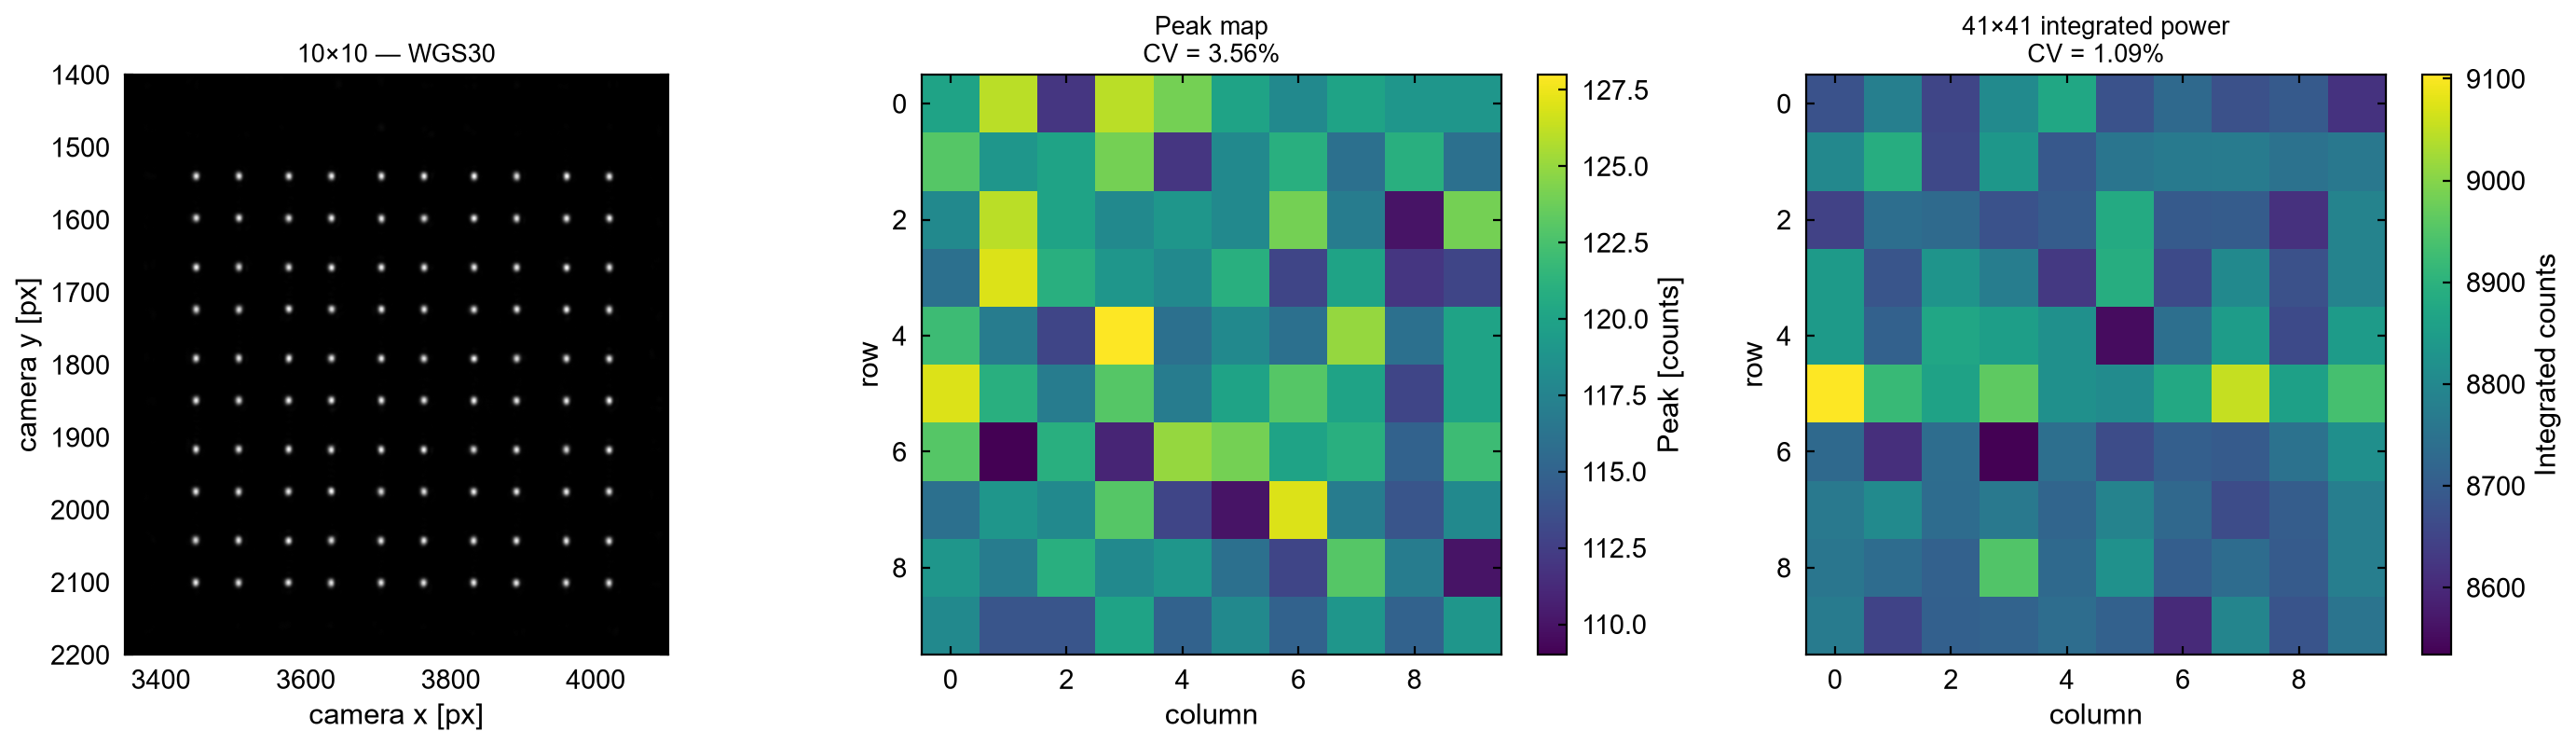

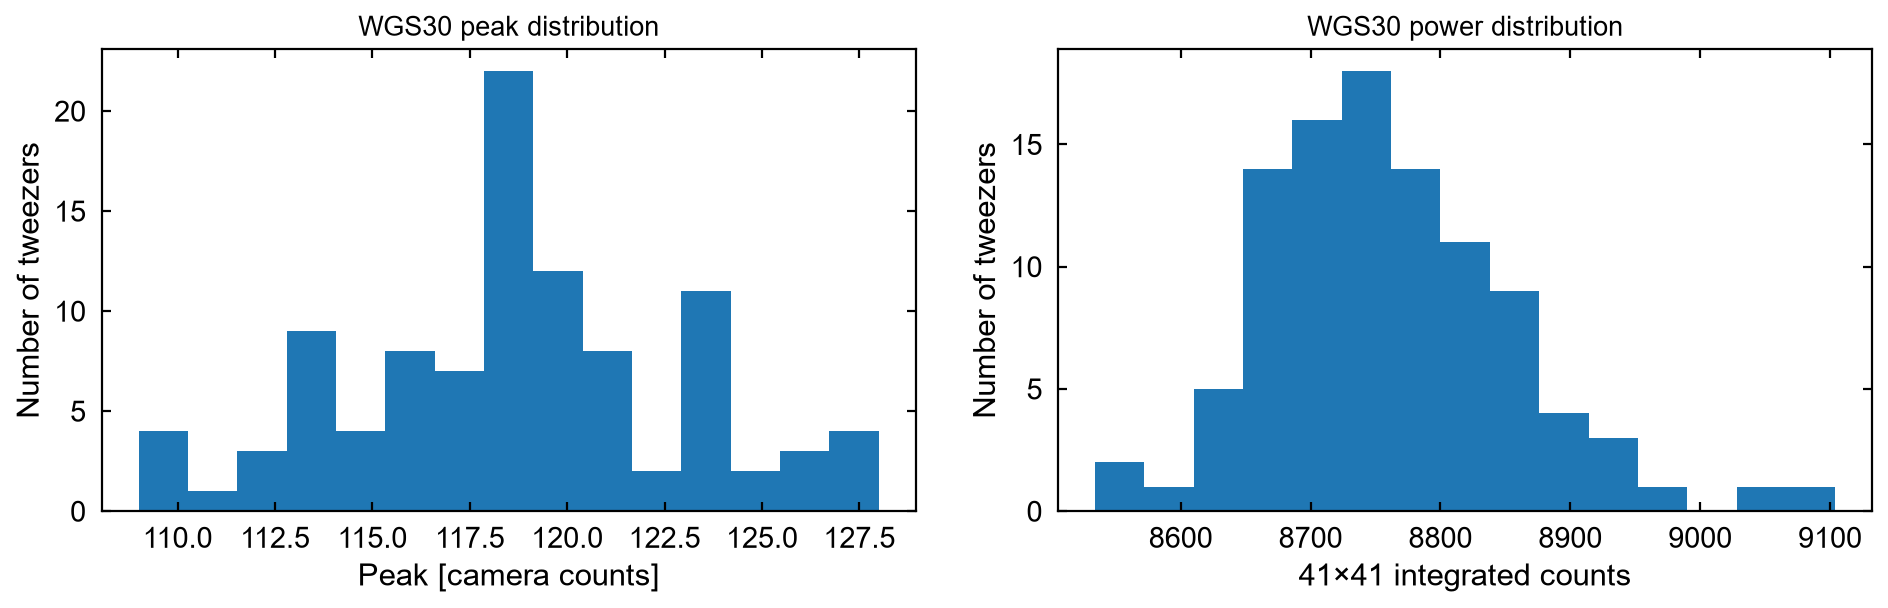

In [23]:
# ============================================================
# VIEW + ANALYZE THE SAVED WGS30 SOLUTION
# ============================================================

from slmsuite.holography import analysis

# ------------------------------------------------------------
# 1. Display the saved WGS30 hologram
#    Wavefront correction stays ON
# ------------------------------------------------------------

slm.set_phase(
    phase_10x10_wgs30_checkpoint,
    phase_correct=True,
    settle=True
)

cam.flush()
img_wgs30_view = cam.get_image()

print("Exposure [us]:", cam.exposure_s * 1e6)
print("Full-frame max:", img_wgs30_view.max())


# ------------------------------------------------------------
# 2. Measure each spot
# ------------------------------------------------------------

spot_ij = np.asarray(holo_10x10.spot_ij)

# Peak measurement: small ROI around each spot
HALF_WIDTH_PEAK = 6

raw_peaks = []

for n in range(spot_ij.shape[1]):

    x = int(round(spot_ij[0, n]))
    y = int(round(spot_ij[1, n]))

    roi = img_wgs30_view[
        y-HALF_WIDTH_PEAK:y+HALF_WIDTH_PEAK+1,
        x-HALF_WIDTH_PEAK:x+HALF_WIDTH_PEAK+1
    ]

    raw_peaks.append(np.max(roi))

raw_peaks = np.asarray(raw_peaks)


# ------------------------------------------------------------
# 3. Exact slmsuite experimental_spot integration
#    41×41 px regions
# ------------------------------------------------------------

pwr_feedback_wgs30_view = analysis.take(
    img_wgs30_view.astype(float),
    spot_ij,
    holo_10x10.spot_integration_width_ij,
    centered=True,
    integrate=True,
)

amp_feedback_wgs30_view = np.sqrt(pwr_feedback_wgs30_view)


# ------------------------------------------------------------
# 4. Statistics helper
# ------------------------------------------------------------

def print_stats(name, arr):
    print(f"\n{name}")
    print("-" * len(name))
    print("min        :", np.min(arr))
    print("median     :", np.median(arr))
    print("mean       :", np.mean(arr))
    print("max        :", np.max(arr))
    print("std        :", np.std(arr))
    print("CV [%]     :", 100 * np.std(arr) / np.mean(arr))
    print("max/min    :", np.max(arr) / np.min(arr))


print("\n========================================")
print("WGS30 — 10×10 ARRAY STATISTICS")
print("========================================")

print_stats("RAW SPOT PEAKS [camera counts]", raw_peaks)

print("\nSaturated spots:",
      np.sum(raw_peaks >= 255), "/ 100")

print_stats(
    "INTEGRATED SPOT POWER [41×41 counts]",
    pwr_feedback_wgs30_view
)

print_stats(
    "SPOT AMPLITUDE [sqrt(counts)]",
    amp_feedback_wgs30_view
)


# ------------------------------------------------------------
# 5. 10×10 maps
# ------------------------------------------------------------

peak_map = raw_peaks.reshape(10, 10)
power_map = pwr_feedback_wgs30_view.reshape(10, 10)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Camera image
axs[0].imshow(
    img_wgs30_view,
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=min(180, raw_peaks.max())
)
axs[0].set_xlim(3350, 4100)
axs[0].set_ylim(2200, 1400)
axs[0].set_title("10×10 — WGS30")
axs[0].set_xlabel("camera x [px]")
axs[0].set_ylabel("camera y [px]")


# Peak map
im1 = axs[1].imshow(
    peak_map,
    cmap="viridis",
    origin="upper"
)
fig.colorbar(im1, ax=axs[1], label="Peak [counts]")
axs[1].set_title(
    f"Peak map\nCV = {100*np.std(raw_peaks)/np.mean(raw_peaks):.2f}%"
)
axs[1].set_xlabel("column")
axs[1].set_ylabel("row")


# Integrated power map
im2 = axs[2].imshow(
    power_map,
    cmap="viridis",
    origin="upper"
)
fig.colorbar(im2, ax=axs[2], label="Integrated counts")
axs[2].set_title(
    f"41×41 integrated power\n"
    f"CV = {100*np.std(pwr_feedback_wgs30_view)/np.mean(pwr_feedback_wgs30_view):.2f}%"
)
axs[2].set_xlabel("column")
axs[2].set_ylabel("row")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Distributions
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(raw_peaks, bins=15)
axs[0].set_xlabel("Peak [camera counts]")
axs[0].set_ylabel("Number of tweezers")
axs[0].set_title("WGS30 peak distribution")

axs[1].hist(pwr_feedback_wgs30_view, bins=15)
axs[1].set_xlabel("41×41 integrated counts")
axs[1].set_ylabel("Number of tweezers")
axs[1].set_title("WGS30 power distribution")

plt.tight_layout()
plt.show()

Comparison summary
Exposure [us] = 2009.681
Integration width [px] = 41

No wavefront correction
-----------------------
Power mean        : 7212.680
Power std         : 579.406
Power CV [%]      : 8.033
Power min         : 5989.000
Power max         : 9395.000
Amp mean          : 84.860
Amp std           : 3.393
Amp CV [%]        : 3.998

Wavefront correction only
-------------------------
Power mean        : 6982.280
Power std         : 542.073
Power CV [%]      : 7.764
Power min         : 5742.000
Power max         : 8773.000
Amp mean          : 83.498
Amp std           : 3.232
Amp CV [%]        : 3.871

Wavefront correction + 30 WGS
-----------------------------
Power mean        : 6812.930
Power std         : 141.980
Power CV [%]      : 2.084
Power min         : 6542.000
Power max         : 7215.000
Amp mean          : 82.536
Amp std           : 0.859
Amp CV [%]        : 1.041



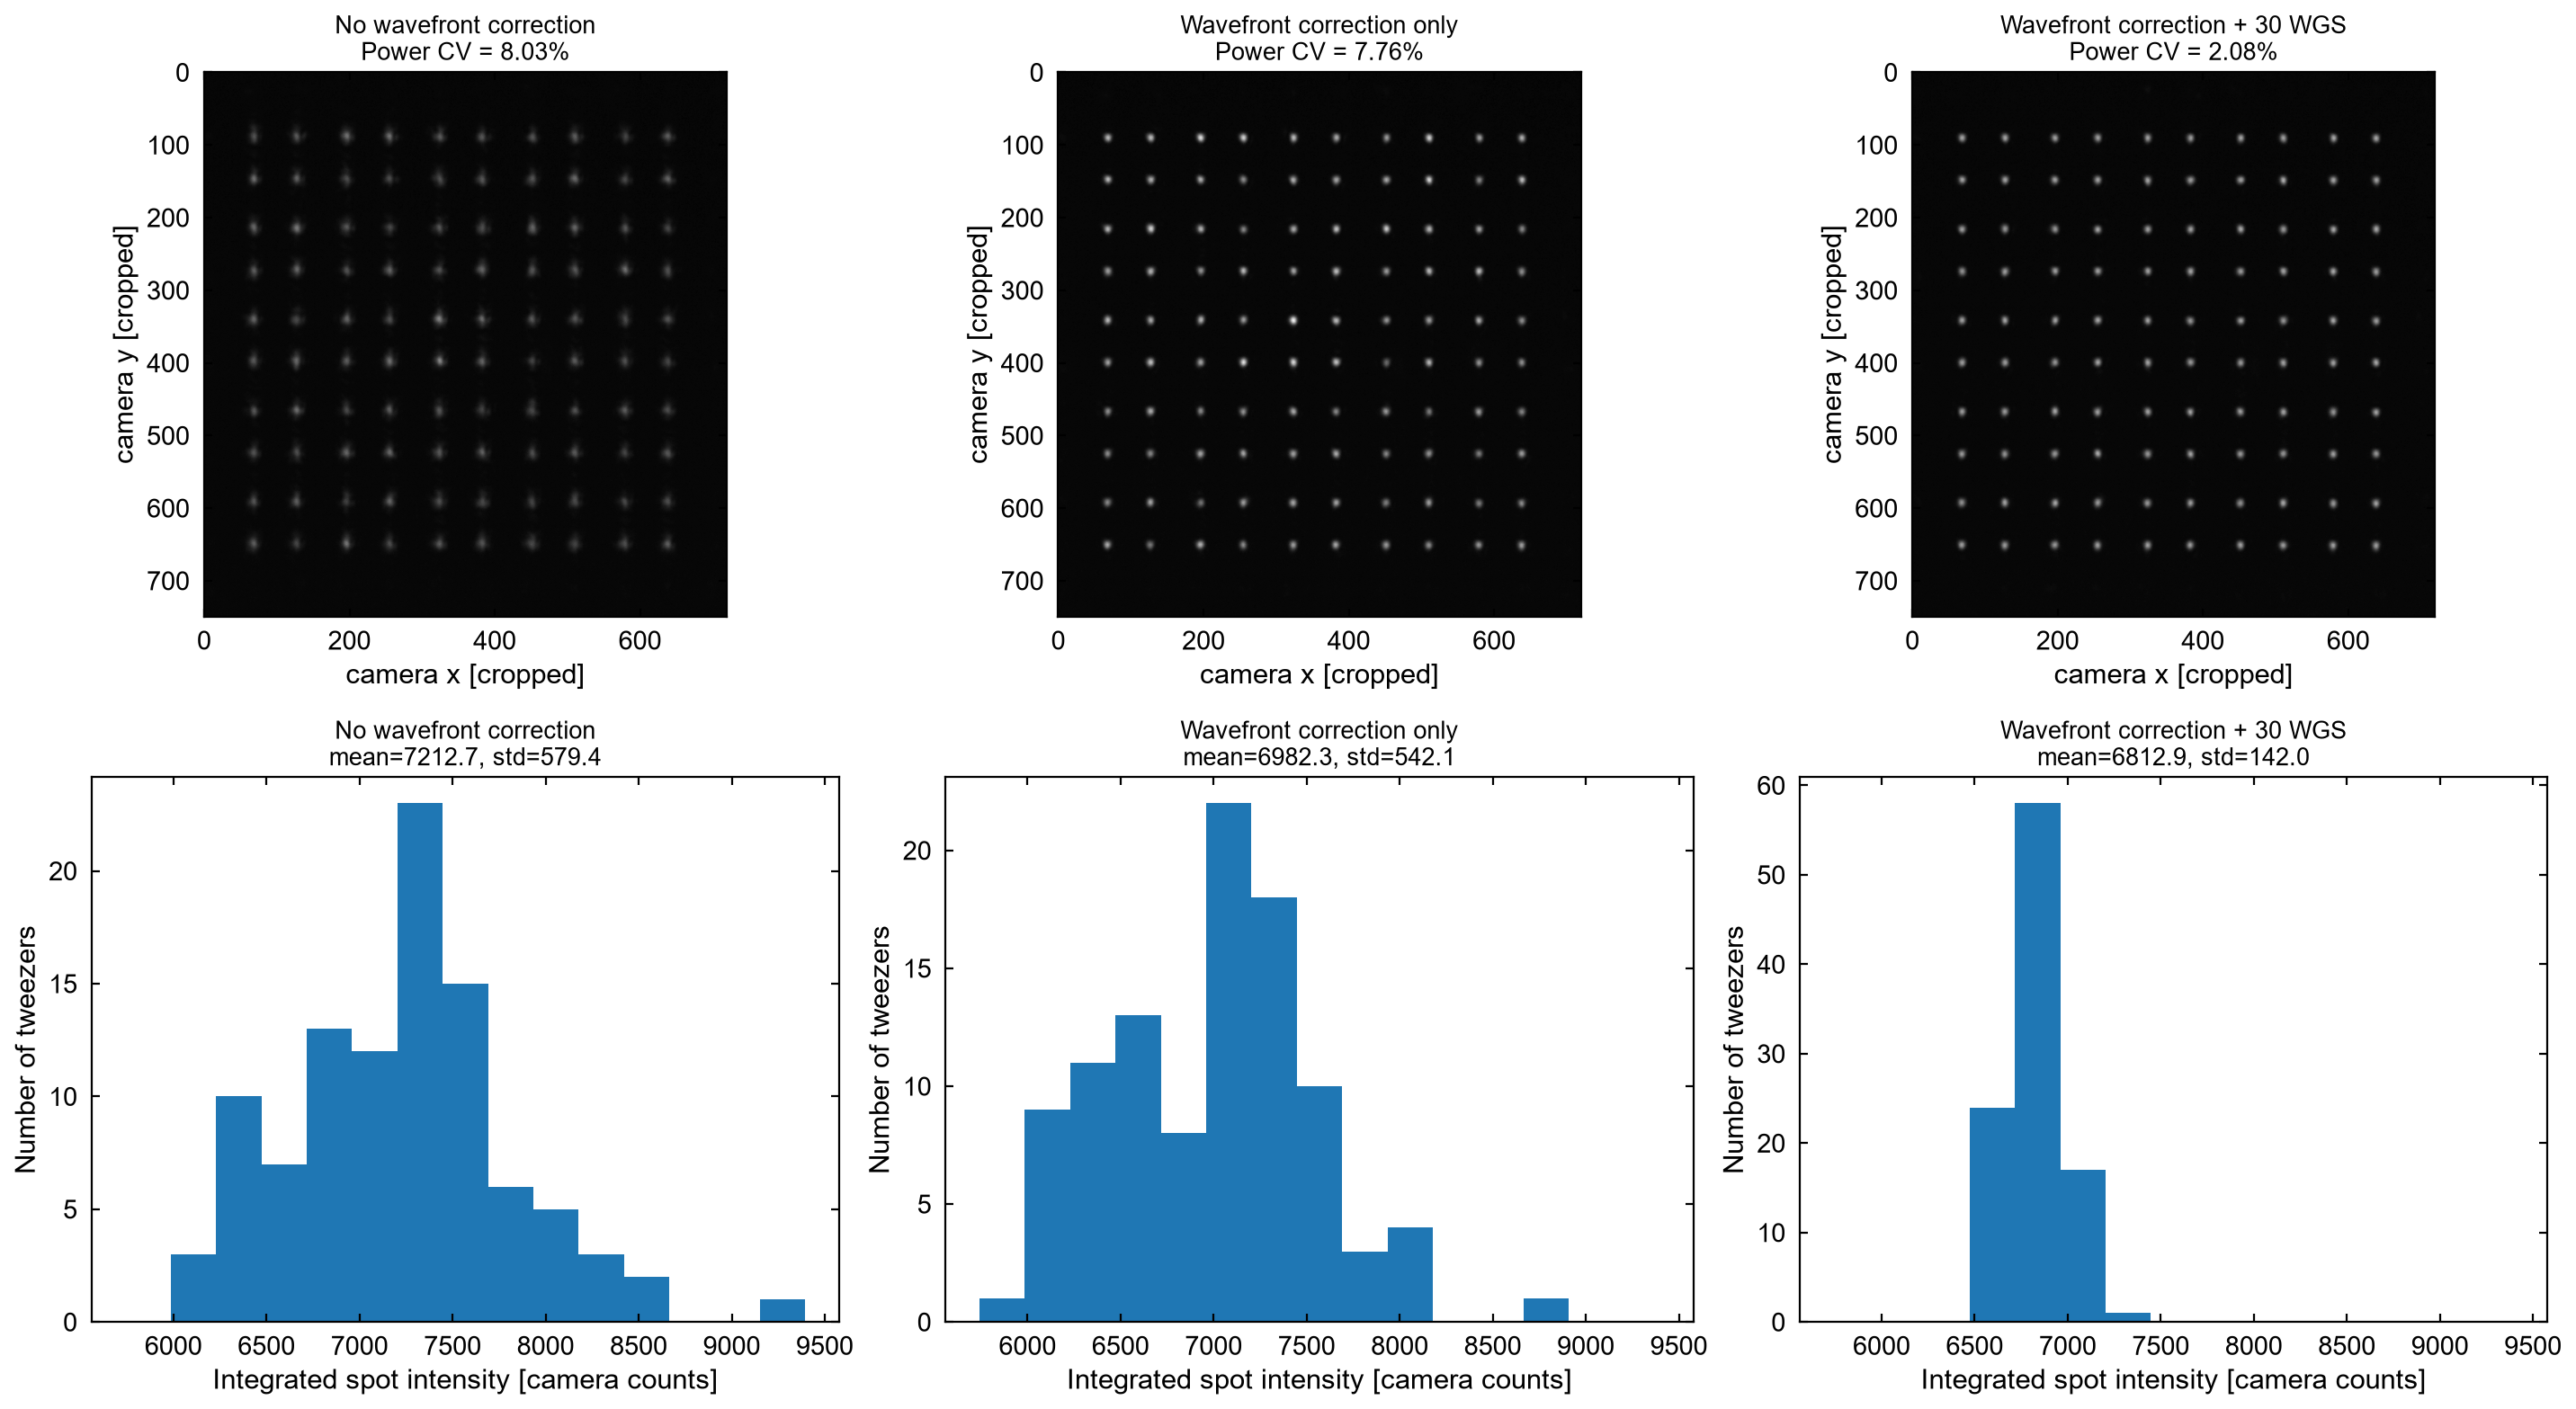

C:\Users\admin\AppData\Local\Temp\ipykernel_2036\2133346963.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


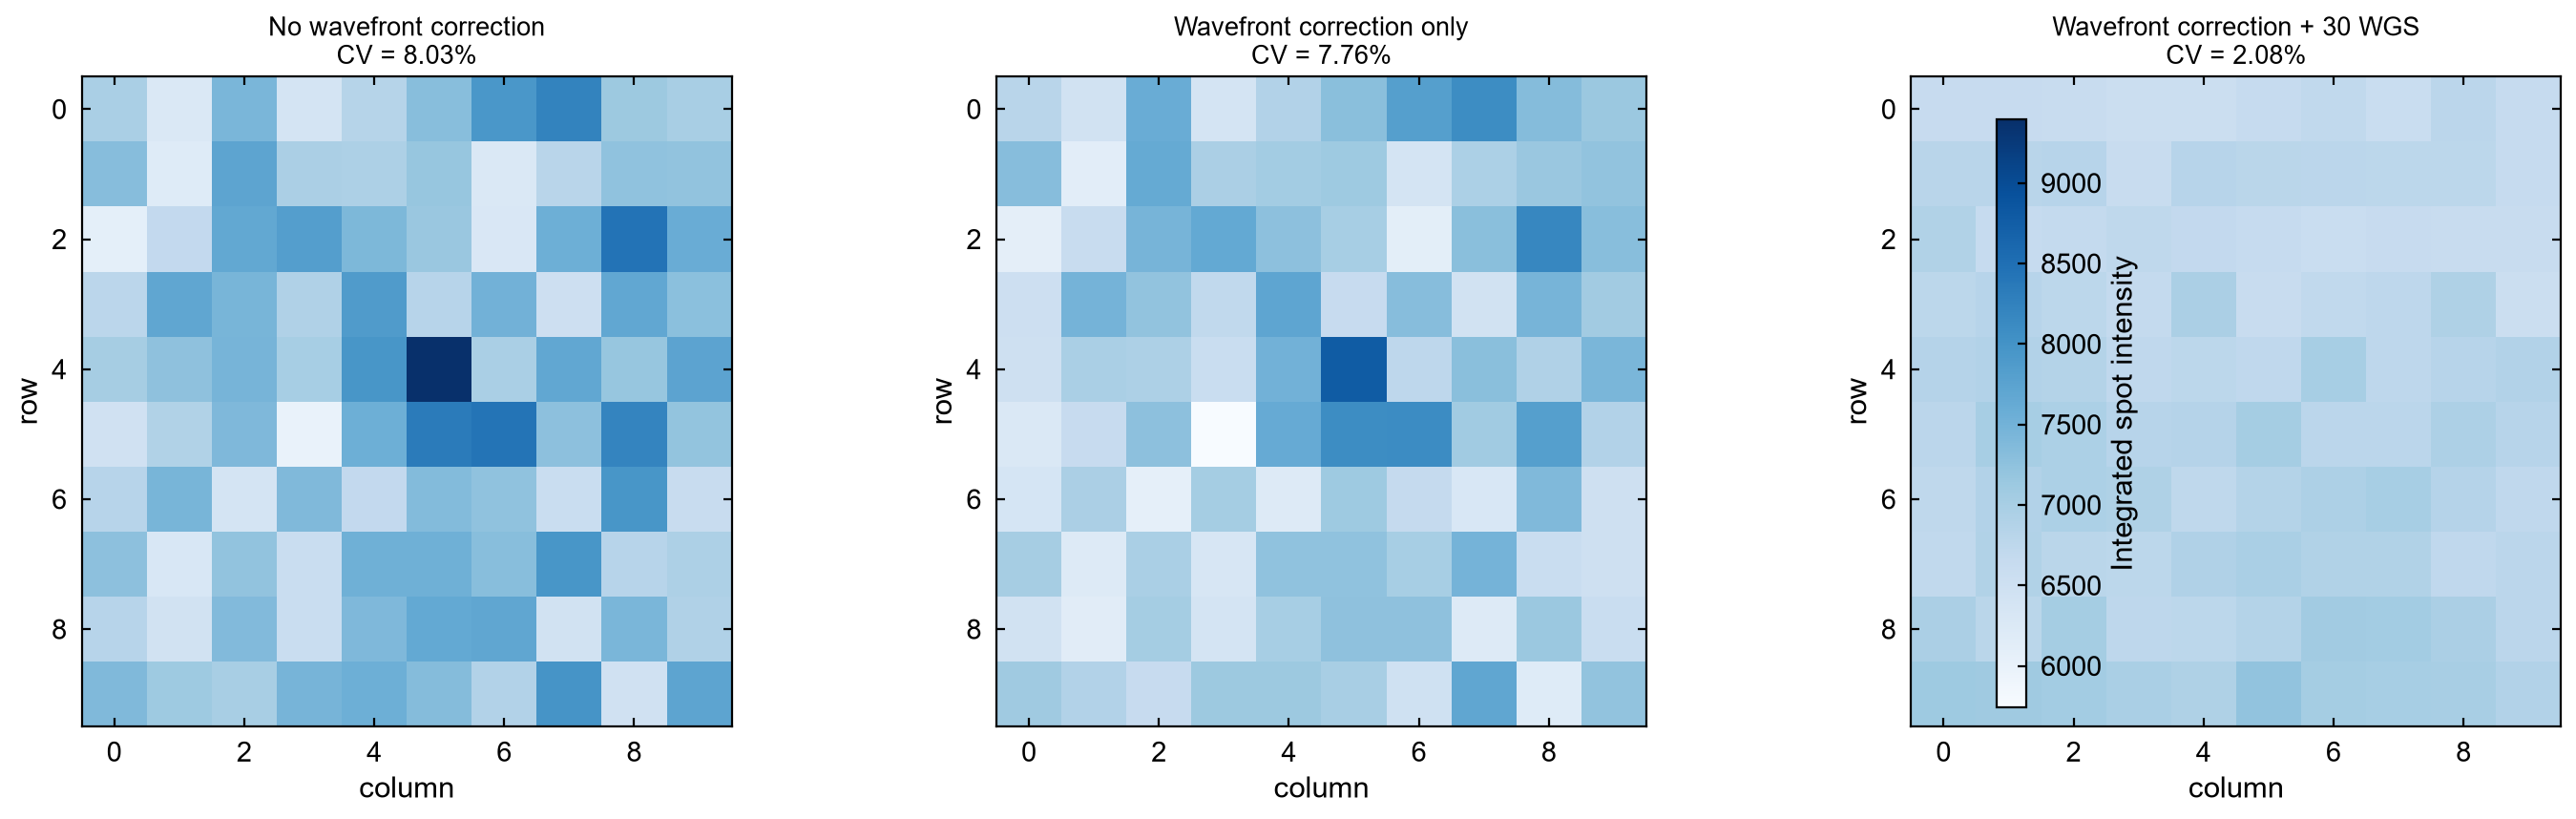

In [26]:
# ============================================================
# COMPARISON PLOT:
# 10x10 GS OFF vs GS+WF vs WGS30+WF
# Camera image + per-spot intensity histogram
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from slmsuite.holography import analysis

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

EXPOSURE_S = 2e-3          # keep fixed for all three states
ROI_X = (3380, 4100)
ROI_Y = (1450, 2200)

# use slmsuite's own integration width so the metric matches WGS
INTEGRATION_WIDTH = holo_10x10.spot_integration_width_ij   # usually 41

# ------------------------------------------------------------
# Helper: acquire one image for a chosen hologram / correction mode
# ------------------------------------------------------------

def acquire_state(phase_holo, phase_correct, label):
    slm.set_phase(
        phase_holo,
        phase_correct=phase_correct,
        settle=True
    )
    cam.set_exposure(EXPOSURE_S)
    cam.flush()
    img = cam.get_image()

    # per-spot integrated powers
    pwr = analysis.take(
        img.astype(float),
        holo_10x10.spot_ij,
        INTEGRATION_WIDTH,
        centered=True,
        integrate=True,
    )

    amp = np.sqrt(pwr)

    result = {
        "label": label,
        "img": img,
        "pwr": np.asarray(pwr),
        "amp": np.asarray(amp),
        "mean_pwr": np.mean(pwr),
        "std_pwr": np.std(pwr),
        "cv_pwr": 100 * np.std(pwr) / np.mean(pwr),
        "min_pwr": np.min(pwr),
        "max_pwr": np.max(pwr),
        "mean_amp": np.mean(amp),
        "std_amp": np.std(amp),
        "cv_amp": 100 * np.std(amp) / np.mean(amp),
    }
    return result

# ------------------------------------------------------------
# Define the three comparison states
# ------------------------------------------------------------

# 1) No wavefront correction: same GS phase, correction OFF
state_off = acquire_state(
    phase_10x10_gs_before_wgs,
    phase_correct=False,
    label="No wavefront correction"
)

# 2) Wavefront correction only: same GS phase, correction ON
state_wf = acquire_state(
    phase_10x10_gs_before_wgs,
    phase_correct=True,
    label="Wavefront correction only"
)

# 3) Wavefront correction + 30 WGS iterations
state_wgs30 = acquire_state(
    phase_10x10_wgs30_checkpoint,
    phase_correct=True,
    label="Wavefront correction + 30 WGS"
)

states = [state_off, state_wf, state_wgs30]

# ------------------------------------------------------------
# Print numerical summary
# ------------------------------------------------------------

print("Comparison summary")
print("=" * 70)
print(f"Exposure [us] = {cam.exposure_s * 1e6:.3f}")
print(f"Integration width [px] = {INTEGRATION_WIDTH}")
print()

for s in states:
    print(s["label"])
    print("-" * len(s["label"]))
    print(f"Power mean        : {s['mean_pwr']:.3f}")
    print(f"Power std         : {s['std_pwr']:.3f}")
    print(f"Power CV [%]      : {s['cv_pwr']:.3f}")
    print(f"Power min         : {s['min_pwr']:.3f}")
    print(f"Power max         : {s['max_pwr']:.3f}")
    print(f"Amp mean          : {s['mean_amp']:.3f}")
    print(f"Amp std           : {s['std_amp']:.3f}")
    print(f"Amp CV [%]        : {s['cv_amp']:.3f}")
    print()

# ------------------------------------------------------------
# Common plotting limits
# ------------------------------------------------------------

# camera image scaling from array ROI only
roi_imgs = [
    s["img"][ROI_Y[0]:ROI_Y[1], ROI_X[0]:ROI_X[1]]
    for s in states
]
vmax_img = max(np.max(r) for r in roi_imgs)

# common histogram range for integrated per-spot power
all_pwr = np.concatenate([s["pwr"] for s in states])
hist_min = np.min(all_pwr)
hist_max = np.max(all_pwr)

# ------------------------------------------------------------
# Figure: top row = camera images, bottom row = histograms
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, s in enumerate(states):
    # ------------------------
    # top: camera image
    # ------------------------
    ax = axes[0, col]
    img_roi = s["img"][ROI_Y[0]:ROI_Y[1], ROI_X[0]:ROI_X[1]]

    im = ax.imshow(
        img_roi,
        cmap="gray",
        origin="upper",
        vmin=0,
        vmax=vmax_img
    )

    ax.set_title(
        f"{s['label']}\n"
        f"Power CV = {s['cv_pwr']:.2f}%"
    )
    ax.set_xlabel("camera x [cropped]")
    ax.set_ylabel("camera y [cropped]")

    # optional: mark predicted spot centers
    x_spots = holo_10x10.spot_ij[0] - ROI_X[0]
    y_spots = holo_10x10.spot_ij[1] - ROI_Y[0]
    # ax.plot(x_spots, y_spots, "wo", ms=3, mfc="none", mew=0.8, color="red")

    # ------------------------
    # bottom: histogram of per-spot integrated power
    # ------------------------
    axh = axes[1, col]
    axh.hist(
        s["pwr"],
        bins=15,
        range=(hist_min, hist_max)
    )
    axh.set_title(
        f"{s['label']}\n"
        f"mean={s['mean_pwr']:.1f}, std={s['std_pwr']:.1f}"
    )
    axh.set_xlabel("Integrated spot intensity [camera counts]")
    axh.set_ylabel("Number of tweezers")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional extra figure:
# 10x10 intensity maps for the three states
# ------------------------------------------------------------

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

all_maps = [s["pwr"].reshape(10, 10) for s in states]
vmin_map = min(np.min(m) for m in all_maps)
vmax_map = max(np.max(m) for m in all_maps)

for ax, s, pmap in zip(axes2, states, all_maps):
    im2 = ax.imshow(
        pmap,
        origin="upper",
        vmin=vmin_map,
        vmax=vmax_map
    )
    ax.set_title(
        f"{s['label']}\n"
        f"CV = {s['cv_pwr']:.2f}%"
    )
    ax.set_xlabel("column")
    ax.set_ylabel("row")

fig2.colorbar(im2, ax=axes2.ravel().tolist(), label="Integrated spot intensity")
plt.tight_layout()
plt.show()

NORMALIZED PEAK INTENSITY COMPARISON
No wavefront correction
-----------------------
mean peak          : 25.020
std peak           : 4.108
peak CV [%]        : 16.421
minimum normalized : 0.7594
maximum normalized : 1.5588

Wavefront correction only
-------------------------
mean peak          : 46.030
std peak           : 7.338
peak CV [%]        : 15.942
minimum normalized : 0.6735
maximum normalized : 1.5425

Wavefront correction + 30 WGS
-----------------------------
mean peak          : 44.490
std peak           : 1.868
peak CV [%]        : 4.199
minimum normalized : 0.8991
maximum normalized : 1.0789



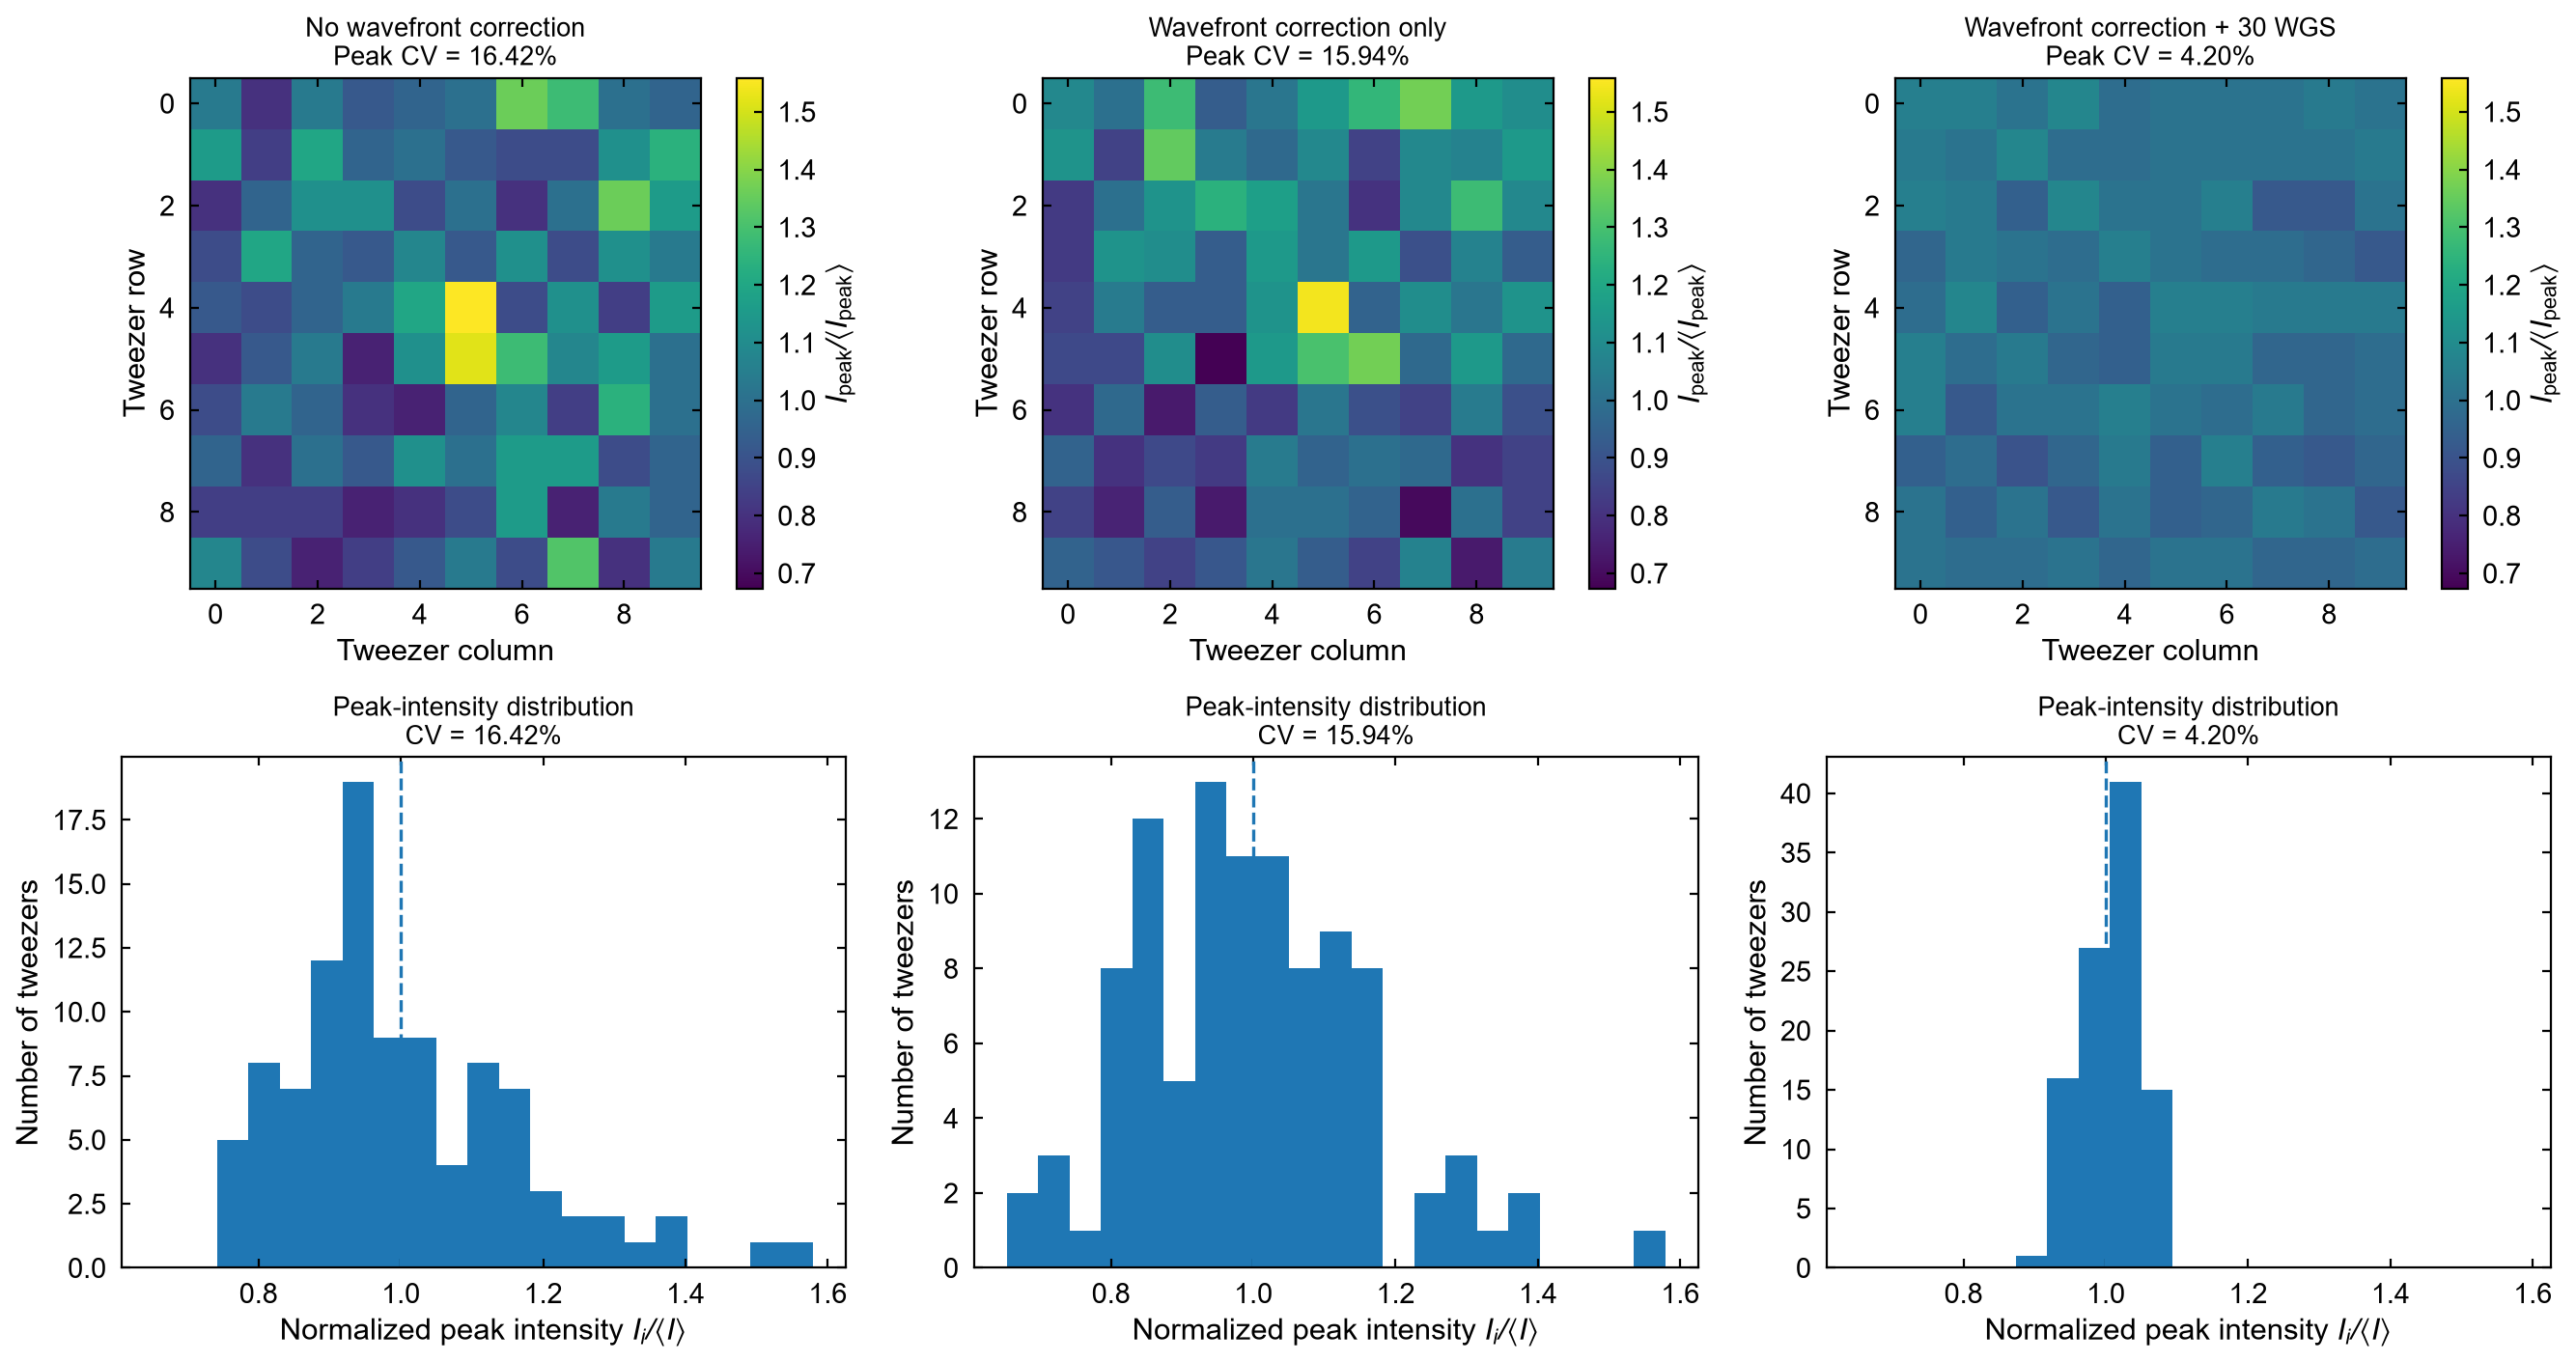

In [28]:
# ============================================================
# NORMALIZED PEAK INTENSITY COMPARISON
# No WF vs WF vs WF + WGS30
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

spot_ij = np.asarray(holo_10x10.spot_ij)

HALF_WIDTH = 6       # 13×13 ROI around each tweezer


# ------------------------------------------------------------
# Extract peak camera intensity for all 100 tweezers
# ------------------------------------------------------------

def extract_peaks(img):

    peaks = []

    for n in range(spot_ij.shape[1]):

        x = int(round(spot_ij[0, n]))
        y = int(round(spot_ij[1, n]))

        roi = img[
            y-HALF_WIDTH:y+HALF_WIDTH+1,
            x-HALF_WIDTH:x+HALF_WIDTH+1
        ]

        peaks.append(np.max(roi))

    return np.asarray(peaks, dtype=float)


peak_nowf = extract_peaks(state_off["img"])
peak_wf   = extract_peaks(state_wf["img"])
peak_wgs  = extract_peaks(state_wgs30["img"])


# ------------------------------------------------------------
# Normalize each condition by its own mean
# ------------------------------------------------------------

norm_nowf = peak_nowf / np.mean(peak_nowf)
norm_wf   = peak_wf   / np.mean(peak_wf)
norm_wgs  = peak_wgs  / np.mean(peak_wgs)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

def summary(name, raw, normalized):

    cv = 100 * np.std(raw) / np.mean(raw)

    print(name)
    print("-" * len(name))
    print(f"mean peak          : {np.mean(raw):.3f}")
    print(f"std peak           : {np.std(raw):.3f}")
    print(f"peak CV [%]        : {cv:.3f}")
    print(f"minimum normalized : {np.min(normalized):.4f}")
    print(f"maximum normalized : {np.max(normalized):.4f}")
    print()


print("NORMALIZED PEAK INTENSITY COMPARISON")
print("=" * 60)

summary(
    "No wavefront correction",
    peak_nowf,
    norm_nowf
)

summary(
    "Wavefront correction only",
    peak_wf,
    norm_wf
)

summary(
    "Wavefront correction + 30 WGS",
    peak_wgs,
    norm_wgs
)


# ------------------------------------------------------------
# Common histogram range
# ------------------------------------------------------------

all_norm = np.concatenate([
    norm_nowf,
    norm_wf,
    norm_wgs
])

bins = np.linspace(
    np.min(all_norm) - 0.02,
    np.max(all_norm) + 0.02,
    22
)


# ------------------------------------------------------------
# Figure
# Top row: normalized 10×10 peak-intensity maps
# Bottom row: normalized peak histograms
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2, 3,
    figsize=(17, 9)
)

states = [
    ("No wavefront correction", norm_nowf),
    ("Wavefront correction only", norm_wf),
    ("Wavefront correction + 30 WGS", norm_wgs),
]

# Use common scale so the maps are directly comparable
vmin = np.min(all_norm)
vmax = np.max(all_norm)

for col, (label, values) in enumerate(states):

    # ----------------------------------------
    # 10×10 normalized peak map
    # ----------------------------------------

    peak_map = values.reshape(10, 10)

    im = axes[0, col].imshow(
        peak_map,
        origin="upper",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    cv = 100 * np.std(values) / np.mean(values)

    axes[0, col].set_title(
        f"{label}\nPeak CV = {cv:.2f}%"
    )

    axes[0, col].set_xlabel("Tweezer column")
    axes[0, col].set_ylabel("Tweezer row")

    fig.colorbar(
        im,
        ax=axes[0, col],
        label=r"$I_{\rm peak}/\langle I_{\rm peak}\rangle$"
    )


    # ----------------------------------------
    # Histogram
    # ----------------------------------------

    axes[1, col].hist(
        values,
        bins=bins
    )

    axes[1, col].axvline(
        1.0,
        linestyle="--"
    )

    axes[1, col].set_xlabel(
        r"Normalized peak intensity $I_i/\langle I\rangle$"
    )

    axes[1, col].set_ylabel(
        "Number of tweezers"
    )

    axes[1, col].set_title(
        f"Peak-intensity distribution\n"
        f"CV = {cv:.2f}%"
    )


plt.tight_layout()
plt.show()